# Algoritmo Ensemble APS - XGBoost/LightGBM compatible para comparacion

Esta version conserva la preparacion de datos, calendario, recursos, rutas y decodificador del notebook `aps_genetico.ipynb`.

A partir de la seccion del algoritmo se sustituye el AG por un enfoque Ensemble orientado a APS:

- Calculo fijo de duraciones de operacion desde CCP: `(TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE`.
- XGBoost se usa solo para estimar la prioridad/secuencia de ordenes, no para estimar duraciones.
- Reglas de prioridad: EDD, SPT, Critical Ratio, slack y riesgo estimado de tardanza.
- Exportacion de resultados, validacion dura, metricas por orden/recurso y comparativas equivalentes al notebook genetico.

Los archivos generados usan prefijo `ens_` para facilitar la comparacion futura con los resultados `ga_`.

In [1]:
import importlib.util
import subprocess
import sys

DEPENDENCIAS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
}

faltantes = [paquete for modulo, paquete in DEPENDENCIAS.items() if importlib.util.find_spec(modulo) is None]

if faltantes:
    print("Instalando dependencias faltantes:", ", ".join(faltantes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
else:
    print("Dependencias ya instaladas.")

# Si xgboost se cargo antes de instalar scikit-learn, hay que recargarlo para que detecte sklearn.
for nombre_modulo in list(sys.modules):
    if nombre_modulo == "xgboost" or nombre_modulo.startswith("xgboost."):
        del sys.modules[nombre_modulo]

import numpy as np
import pandas as pd
import matplotlib
import sklearn
import xgboost

print("Python:", sys.executable)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

Dependencias ya instaladas.
Python: /home/antonio/Python/env_jupyter/bin/python
numpy: 2.4.6
pandas: 3.0.3
matplotlib: 3.10.9
scikit-learn: 1.9.0
xgboost: 3.2.0


## 1. Imports y configuración

In [2]:
from pathlib import Path
from datetime import datetime, timedelta
from collections import OrderedDict, defaultdict
import math
import random
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 2. Resolución robusta de rutas

In [3]:
def resolver_carpeta_ejecucion():
    """Devuelve la carpeta del archivo/notebook que se está ejecutando."""
    archivo_actual = globals().get("__file__")
    if archivo_actual and Path(archivo_actual).exists():
        return Path(archivo_actual).resolve().parent

    notebook_name = "aps_ensemble.ipynb"
    cwd = Path.cwd().resolve()
    candidatos = [cwd / notebook_name, cwd / "tfm" / "algoritmos" / notebook_name]
    try:
        candidatos.extend(cwd.glob(f"**/{notebook_name}"))
    except OSError:
        pass

    for ruta in candidatos:
        if ruta.exists():
            return ruta.resolve().parent
    return cwd


def resolver_rutas():
    """Localiza los CSV desde la carpeta del codigo, su padre y rutas conocidas."""
    carpeta_codigo = resolver_carpeta_ejecucion()
    candidatos_raiz = [
        carpeta_codigo,
        carpeta_codigo.parent,
        Path("/workspace/tfm"),
        Path("/opt/projects/tfm"),
        Path("/workspace/projects/tfm"),
        Path("/mnt/data"),
        Path.cwd(),
    ]
    subdirs_datos = ["datos_ofuscados", ""]
    output_dir = carpeta_codigo / "output"

    for raiz in candidatos_raiz:
        for sub in subdirs_datos:
            data_dir = raiz / sub if sub else raiz
            if (data_dir / "PLAN.csv").exists() and (data_dir / "CCP.csv").exists():
                return raiz, data_dir, output_dir
    raise FileNotFoundError("No se encontraron PLAN.csv y CCP.csv en las rutas esperadas.")

ROOT_DIR, DATA_DIR, OUTPUT_DIR = resolver_rutas()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLAN_PATH = DATA_DIR / "PLAN.csv"
CCP_PATH = DATA_DIR / "CCP.csv"
LPA_GAM_PATH = DATA_DIR / "LPA_GAM.csv" if (DATA_DIR / "LPA_GAM.csv").exists() else ROOT_DIR / "LPA_GAM.csv"
LPA_GSM_PATH = DATA_DIR / "LPA_GSM.csv" if (DATA_DIR / "LPA_GSM.csv").exists() else ROOT_DIR / "LPA_GSM.csv"

print("ROOT_DIR :", ROOT_DIR)
print("DATA_DIR :", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PLAN     :", PLAN_PATH)
print("CCP      :", CCP_PATH)
print("LPA_GAM  :", LPA_GAM_PATH)
print("LPA_GSM  :", LPA_GSM_PATH)

ROOT_DIR : /opt/projects/tfm
DATA_DIR : /opt/projects/tfm/datos_ofuscados
OUTPUT_DIR: /opt/projects/tfm/algoritmos/output
PLAN     : /opt/projects/tfm/datos_ofuscados/PLAN.csv
CCP      : /opt/projects/tfm/datos_ofuscados/CCP.csv
LPA_GAM  : /opt/projects/tfm/datos_ofuscados/LPA_GAM.csv
LPA_GSM  : /opt/projects/tfm/datos_ofuscados/LPA_GSM.csv


## 3. Carga y primera inspección de datos

In [4]:
def leer_csv(path, **kwargs):
    return pd.read_csv(path, sep=";", encoding="utf-8-sig", **kwargs)

plan_df = leer_csv(
    PLAN_PATH,
    parse_dates=["FECHA_PROVEEDOR", "FECHA_ENTREGA"],
)
ccp_df = leer_csv(CCP_PATH)
lpa_gam = leer_csv(
    LPA_GAM_PATH,
    parse_dates=["COMIENZO_OPERACION", "FIN_OPERACION", "FECHA_CALCULO_PLAN"],
)
lpa_gsm = leer_csv(
    LPA_GSM_PATH,
    parse_dates=["COMIENZO_OPERACION", "FIN_OPERACION", "FECHA_CALCULO_PLAN"],
)
lpa_df = pd.concat([lpa_gam, lpa_gsm], ignore_index=True)

print("PLAN:", plan_df.shape)
print("CCP :", ccp_df.shape)
print("LPA :", lpa_df.shape)
print("\nColumnas PLAN:", list(plan_df.columns))
print("Columnas CCP :", list(ccp_df.columns))
print("Columnas LPA :", list(lpa_df.columns))

PLAN: (14983, 8)
CCP : (35789, 10)
LPA : (12829, 13)

Columnas PLAN: ['ORDEN', 'PARTNUMBER', 'CANTIDAD', 'CENTRO', 'FECHA_PROVEEDOR', 'FECHA_PROVEEDOR_REAL', 'FECHA_ENTREGA', 'CLIENTE']
Columnas CCP : ['PARTNUMBER', 'OPERACION', 'POSTURA', 'RECURSO', 'TECNOLOGIA', 'CENTRO_MECANIZADO', 'PIEZAS_SIMULTANEAS', 'TIEMPO_FIJO_MIN', 'TIEMPO_VARIABLE_MIN', 'OEE']
Columnas LPA : ['ORDEN', 'OPERACION', 'RECURSO', 'PARTNUMBER', 'CANTIDAD', 'COMIENZO_OPERACION', 'FIN_OPERACION', 'TIEMPO_PREPARACION', 'TIEMPO_PROCESO', 'GRUPO_RECURSO', 'MULTIPLICIDAD', 'DURACION_CCP', 'FECHA_CALCULO_PLAN']


## 4. Limpieza de órdenes sin datos CCP, sin tiempos CCP o sin OEE

Limpieza de órdenes con fecha de proveedor en atraso configurable (por defecto, True)

In [5]:
# Parametros configurables del alcance de planificacion.
# MODO_PLANIFICACION_ORDENES:
# - "TODAS": planifica todas las ordenes de PLAN que superen la limpieza de datos.
# - "SOLO_LPA": planifica solo las ordenes de PLAN cuyo codigo ORDEN aparece en LPA_GAM o LPA_GSM.
MODO_PLANIFICACION_ORDENES = "SOLO_LPA"
ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA = True
FECHA_REFERENCIA_ATRASO_PROVEEDOR = pd.Timestamp(lpa_df["FECHA_CALCULO_PLAN"].dropna().min()).floor("D")

MODOS_PLANIFICACION_VALIDOS = {"TODAS", "SOLO_LPA"}
if MODO_PLANIFICACION_ORDENES not in MODOS_PLANIFICACION_VALIDOS:
    raise ValueError(
        "MODO_PLANIFICACION_ORDENES debe ser uno de "
        f"{sorted(MODOS_PLANIFICACION_VALIDOS)}"
    )

# Primero se detectan los PARTNUMBER cuya ruta CCP no es utilizable.
# Se invalidan si alguna operacion no tiene tiempos u OEE usable.
tiempo_cols = ["TIEMPO_FIJO_MIN", "TIEMPO_VARIABLE_MIN"]
tiempos_ccp = ccp_df[tiempo_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", ".", regex=False), errors="coerce")
)
oee_ccp = pd.to_numeric(
    ccp_df["OEE"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)

partnumber_ccp = ccp_df["PARTNUMBER"].astype("string")
partnumbers_ccp = set(partnumber_ccp.dropna().astype(str))
mascara_ccp_tiempo_cero = tiempos_ccp.fillna(0.0).sum(axis=1).le(0.0)
mascara_ccp_oee_invalido = oee_ccp.isna() | oee_ccp.eq(0)
partnumbers_ccp_tiempo_cero = set(
    partnumber_ccp[mascara_ccp_tiempo_cero & partnumber_ccp.notna()].astype(str)
)
partnumbers_ccp_oee_invalido = set(
    partnumber_ccp[mascara_ccp_oee_invalido & partnumber_ccp.notna()].astype(str)
)
partnumbers_ccp_validos = partnumbers_ccp - partnumbers_ccp_tiempo_cero - partnumbers_ccp_oee_invalido

# Despues se filtran las ordenes de PLAN antes de ejecutar cualquier parte del algoritmo.
# Primero se aplica el alcance elegido: todas las ordenes o solo las ya presentes en LPA.
n_plan_original = len(plan_df)
ordenes_lpa = set(lpa_df["ORDEN"].dropna().astype(str))
orden_plan = plan_df["ORDEN"].astype("string")
mascara_plan_en_lpa = orden_plan.notna() & orden_plan.astype(str).isin(ordenes_lpa)
n_ordenes_plan_fuera_lpa = int((~mascara_plan_en_lpa).sum())
ordenes_plan_fuera_lpa = plan_df.loc[
    ~mascara_plan_en_lpa,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_fuera_lpa["MOTIVO"] = "ORDEN no aparece en LPA_GAM ni LPA_GSM"

if MODO_PLANIFICACION_ORDENES == "SOLO_LPA":
    plan_df = plan_df.loc[mascara_plan_en_lpa].reset_index(drop=True)
else:
    ordenes_plan_fuera_lpa = ordenes_plan_fuera_lpa.iloc[0:0].copy()

# Se eliminan las ordenes sin datos CCP, con tiempos CCP a cero o con OEE CCP sin valor/cero.
partnumber_plan = plan_df["PARTNUMBER"].astype("string")
mascara_plan_con_ccp = partnumber_plan.notna() & partnumber_plan.isin(partnumbers_ccp)
mascara_plan_con_ccp_valido = partnumber_plan.notna() & partnumber_plan.isin(partnumbers_ccp_validos)
mascara_plan_ccp_tiempo_cero = mascara_plan_con_ccp & partnumber_plan.isin(partnumbers_ccp_tiempo_cero)
mascara_plan_ccp_oee_invalido = mascara_plan_con_ccp & partnumber_plan.isin(partnumbers_ccp_oee_invalido)

ordenes_plan_sin_ccp = plan_df.loc[
    ~mascara_plan_con_ccp,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_sin_ccp["MOTIVO"] = "PARTNUMBER no aparece en CCP"

ordenes_plan_ccp_tiempo_cero = plan_df.loc[
    mascara_plan_ccp_tiempo_cero,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_ccp_tiempo_cero["MOTIVO"] = "PARTNUMBER con duracion base CCP a cero"

ordenes_plan_ccp_oee_invalido = plan_df.loc[
    mascara_plan_ccp_oee_invalido,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_ccp_oee_invalido["MOTIVO"] = "PARTNUMBER con OEE CCP sin valor o cero"

def motivo_descarte_plan(partnumber):
    if pd.isna(partnumber):
        return "PARTNUMBER vacio en PLAN"

    pn = str(partnumber)
    if pn not in partnumbers_ccp:
        return "PARTNUMBER no aparece en CCP"

    motivos = []
    if pn in partnumbers_ccp_tiempo_cero:
        motivos.append("duracion base CCP a cero")
    if pn in partnumbers_ccp_oee_invalido:
        motivos.append("OEE CCP sin valor o cero")
    return "; ".join(motivos)

ordenes_plan_descartadas = plan_df.loc[
    ~mascara_plan_con_ccp_valido,
    ["ORDEN", "PARTNUMBER"],
].copy()
ordenes_plan_descartadas["MOTIVO"] = ordenes_plan_descartadas["PARTNUMBER"].apply(motivo_descarte_plan)
ordenes_plan_descartadas = pd.concat(
    [ordenes_plan_fuera_lpa, ordenes_plan_descartadas],
    ignore_index=True,
    sort=False,
)

plan_df = plan_df.loc[mascara_plan_con_ccp_valido].reset_index(drop=True)

# Opcionalmente se eliminan ordenes cuya fecha de proveedor ya esta vencida
# respecto a la fecha de referencia del plan.
fecha_proveedor_plan = pd.to_datetime(plan_df["FECHA_PROVEEDOR"], errors="coerce")
mascara_plan_fecha_proveedor_atrasada = fecha_proveedor_plan < FECHA_REFERENCIA_ATRASO_PROVEEDOR
ordenes_plan_fecha_proveedor_atrasada = plan_df.loc[
    mascara_plan_fecha_proveedor_atrasada,
    ["ORDEN", "PARTNUMBER", "FECHA_PROVEEDOR"],
].copy()
ordenes_plan_fecha_proveedor_atrasada["MOTIVO"] = (
    "FECHA_PROVEEDOR anterior a " + str(FECHA_REFERENCIA_ATRASO_PROVEEDOR.date())
)

if ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA:
    ordenes_plan_descartadas = pd.concat(
        [ordenes_plan_descartadas, ordenes_plan_fecha_proveedor_atrasada],
        ignore_index=True,
        sort=False,
    )
    plan_df = plan_df.loc[~mascara_plan_fecha_proveedor_atrasada].reset_index(drop=True)

print("Modo planificacion ordenes:", MODO_PLANIFICACION_ORDENES)
print("Ordenes PLAN antes de limpieza:", n_plan_original)
print("Ordenes PLAN fuera de LPA:", n_ordenes_plan_fuera_lpa)
print("Ordenes eliminadas sin PARTNUMBER en CCP:", len(ordenes_plan_sin_ccp))
print("Ordenes afectadas por duracion base CCP a cero:", len(ordenes_plan_ccp_tiempo_cero))
print("Ordenes afectadas por OEE CCP sin valor o cero:", len(ordenes_plan_ccp_oee_invalido))
print("Eliminar ordenes con FECHA_PROVEEDOR atrasada:", ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA)
print("Fecha referencia atraso proveedor:", FECHA_REFERENCIA_ATRASO_PROVEEDOR.date())
print("Ordenes con FECHA_PROVEEDOR atrasada:", len(ordenes_plan_fecha_proveedor_atrasada))
print("Ordenes descartadas totales:", len(ordenes_plan_descartadas))
print("Ordenes PLAN despues de limpieza:", len(plan_df))
ordenes_plan_descartadas.head()

Modo planificacion ordenes: SOLO_LPA
Ordenes PLAN antes de limpieza: 14983
Ordenes PLAN fuera de LPA: 10820
Ordenes eliminadas sin PARTNUMBER en CCP: 25
Ordenes afectadas por duracion base CCP a cero: 49
Ordenes afectadas por OEE CCP sin valor o cero: 166
Eliminar ordenes con FECHA_PROVEEDOR atrasada: True
Fecha referencia atraso proveedor: 2026-05-19
Ordenes con FECHA_PROVEEDOR atrasada: 1599
Ordenes descartadas totales: 12655
Ordenes PLAN despues de limpieza: 2328


,ORDEN,PARTNUMBER,MOTIVO,FECHA_PROVEEDOR
0,ORDEN_0,PARTNUMBER_0,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
1,ORDEN_1,PARTNUMBER_1,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
2,ORDEN_3,PARTNUMBER_3,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
3,ORDEN_4,PARTNUMBER_4,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT
4,ORDEN_5,PARTNUMBER_5,ORDEN no aparece en LPA_GAM ni LPA_GSM,NaT


## 5. Generación de RECURSOS.csv desde LPA_GAM y LPA_GSM

In [6]:
recursos_path = OUTPUT_DIR / "RECURSOS.csv"

def normalizar_recursos(df):
    return (
        df[["RECURSO", "GRUPO_RECURSO"]]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values(["GRUPO_RECURSO", "RECURSO"])
        .reset_index(drop=True)
    )

# RECURSOS.csv debe salir de las apariciones RECURSO/GRUPO_RECURSO de LPA_GAM y LPA_GSM.
if recursos_path.exists():
    recursos_df = normalizar_recursos(leer_csv(recursos_path))
    print("RECURSOS.csv cargado desde:", recursos_path)
else:
    recursos_df = normalizar_recursos(lpa_df)
    recursos_df.to_csv(recursos_path, sep=";", index=False)
    print("RECURSOS.csv guardado en:", recursos_path)

recursos_por_grupo = (
    recursos_df.groupby("GRUPO_RECURSO")["RECURSO"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)
maquina_to_groups = (
    recursos_df.groupby("RECURSO")["GRUPO_RECURSO"]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)
available_groups = set(recursos_por_grupo)

print("Pares recurso/grupo:", len(recursos_df))
print("Máquinas únicas:", recursos_df["RECURSO"].nunique())
print("Grupos únicos:", recursos_df["GRUPO_RECURSO"].nunique())
recursos_df.head()

RECURSOS.csv cargado desde: /opt/projects/tfm/algoritmos/output/RECURSOS.csv
Pares recurso/grupo: 229
Máquinas únicas: 153
Grupos únicos: 153


,RECURSO,GRUPO_RECURSO
0,RECURSO_170,GRUPO_RECURSO_0
1,RECURSO_177,GRUPO_RECURSO_0
2,RECURSO_187,GRUPO_RECURSO_0
3,RECURSO_199,GRUPO_RECURSO_0
4,RECURSO_187,GRUPO_RECURSO_1


## 6. Inferencia de GRUPO_RECURSO para los registros CCP

In [7]:
def moda_o_primero(serie):
    vc = serie.dropna().astype(str).value_counts()
    return vc.index[0] if len(vc) else pd.NA

# En el CCP real recibido no existe una columna GRUPO_RECURSO; aparece como RECURSO.
# Por eso se infiere el grupo compatible usando las secuencias Asprova como referencia.
lpa_key_to_group = (
    lpa_df.groupby(["PARTNUMBER", "OPERACION"])["GRUPO_RECURSO"]
    .agg(moda_o_primero)
    .to_dict()
)

# Fallback: para cada RECURSO de CCP, grupo más observado al cruzar CCP con LPA por partnumber/operación.
joined_lpa_ccp = lpa_df[["PARTNUMBER", "OPERACION", "GRUPO_RECURSO"]].merge(
    ccp_df[["PARTNUMBER", "OPERACION", "RECURSO"]].rename(columns={"RECURSO": "CCP_RECURSO"}),
    on=["PARTNUMBER", "OPERACION"],
    how="inner",
)
ccp_resource_to_group = (
    joined_lpa_ccp.groupby("CCP_RECURSO")["GRUPO_RECURSO"]
    .agg(moda_o_primero)
    .to_dict()
)

def inferir_grupo_ccp(row):
    key = (row["PARTNUMBER"], row["OPERACION"])
    if key in lpa_key_to_group:
        return lpa_key_to_group[key], "lpa_partnumber_operacion"

    recurso_ccp = str(row["RECURSO"])
    if recurso_ccp in ccp_resource_to_group:
        return ccp_resource_to_group[recurso_ccp], "ccp_recurso_dominante"

    if recurso_ccp in maquina_to_groups and maquina_to_groups[recurso_ccp]:
        return maquina_to_groups[recurso_ccp][0], "maquina_directa"

    grupo_por_numero = recurso_ccp.replace("RECURSO_", "GRUPO_RECURSO_")
    if grupo_por_numero in available_groups:
        return grupo_por_numero, "conversion_numerica"

    return pd.NA, "sin_mapeo"

mapeo = ccp_df.apply(inferir_grupo_ccp, axis=1, result_type="expand")
ccp_df["GRUPO_RECURSO"] = mapeo[0]
ccp_df["MAPEO_GRUPO"] = mapeo[1]

print("Método de mapeo CCP -> GRUPO_RECURSO:")
print(ccp_df["MAPEO_GRUPO"].value_counts(dropna=False))
print("\nRegistros CCP sin grupo válido:", int((~ccp_df["GRUPO_RECURSO"].isin(available_groups)).sum()))
print("Registros CCP totales:", len(ccp_df))
ccp_df.head()

Método de mapeo CCP -> GRUPO_RECURSO:
MAPEO_GRUPO
ccp_recurso_dominante       17519
conversion_numerica         13531
lpa_partnumber_operacion     4711
sin_mapeo                      15
maquina_directa                13
Name: count, dtype: int64

Registros CCP sin grupo válido: 15
Registros CCP totales: 35789


,PARTNUMBER,OPERACION,POSTURA,RECURSO,TECNOLOGIA,CENTRO_MECANIZADO,PIEZAS_SIMULTANEAS,TIEMPO_FIJO_MIN,TIEMPO_VARIABLE_MIN,OEE,GRUPO_RECURSO,MAPEO_GRUPO
0,PARTNUMBER_6373,800020,POSTURA_0,RECURSO_0,TECNOLOGIA_0,CENTRO_MECANIZADO_0,1,10.0,10.89,68.1,GRUPO_RECURSO_2,ccp_recurso_dominante
1,PARTNUMBER_6374,800020,POSTURA_0,RECURSO_0,TECNOLOGIA_0,CENTRO_MECANIZADO_0,1,10.0,10.89,68.1,GRUPO_RECURSO_2,ccp_recurso_dominante
2,PARTNUMBER_6375,1300020,POSTURA_0,RECURSO_0,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,360.0,25.00,45.0,GRUPO_RECURSO_2,ccp_recurso_dominante
3,PARTNUMBER_6375,1300030,POSTURA_1,RECURSO_0,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,120.0,10.00,40.0,GRUPO_RECURSO_2,ccp_recurso_dominante
4,PARTNUMBER_6376,800020,POSTURA_0,RECURSO_1,TECNOLOGIA_1,CENTRO_MECANIZADO_0,1,120.0,50.00,40.0,GRUPO_RECURSO_18,ccp_recurso_dominante


## 7. Construcción de rutas de fabricación por partnumber

In [8]:
# Normalización de tipos numéricos.
ccp_valid = ccp_df[ccp_df["GRUPO_RECURSO"].isin(available_groups)].copy()
for col in ["OPERACION", "PIEZAS_SIMULTANEAS"]:
    ccp_valid[col] = pd.to_numeric(ccp_valid[col], errors="coerce").fillna(0).astype(int)
for col in ["TIEMPO_FIJO_MIN", "TIEMPO_VARIABLE_MIN", "OEE"]:
    ccp_valid[col] = pd.to_numeric(ccp_valid[col], errors="coerce").fillna(0.0)

# Rutas por partnumber. Si hay varias alternativas para un mismo PARTNUMBER/OPERACION,
# se conservan todas y el decodificador elegirá la que termine antes según disponibilidad.
routes_by_pn = {}
for pn, dfpn in ccp_valid.sort_values(["PARTNUMBER", "OPERACION"]).groupby("PARTNUMBER"):
    ops = []
    for op_code, dfop in dfpn.groupby("OPERACION", sort=True):
        alternativas = []
        for _, r in dfop.iterrows():
            oee = float(r["OEE"]) if float(r["OEE"]) > 0 else 100.0
            multiplicidad = int(r["PIEZAS_SIMULTANEAS"]) if int(r["PIEZAS_SIMULTANEAS"]) > 0 else 1
            alternativas.append({
                "operacion": int(op_code),
                "grupo": str(r["GRUPO_RECURSO"]),
                "ccp_recurso": str(r["RECURSO"]),
                "postura": str(r.get("POSTURA", "")),
                "tecnologia": str(r.get("TECNOLOGIA", "")),
                "centro_mecanizado": str(r.get("CENTRO_MECANIZADO", "")),
                "tfijo": float(r["TIEMPO_FIJO_MIN"]),
                "tvar": float(r["TIEMPO_VARIABLE_MIN"]),
                "oee": oee,
                "mul": multiplicidad,
                "mapeo_grupo": str(r.get("MAPEO_GRUPO", "")),
            })
        ops.append({"operacion": int(op_code), "alternativas": alternativas})
    routes_by_pn[str(pn)] = ops

print("Partnumbers con ruta CCP válida:", len(routes_by_pn))
print("Operaciones CCP válidas:", len(ccp_valid))

Partnumbers con ruta CCP válida: 11164
Operaciones CCP válidas: 35774


## 8. Construcción de órdenes planificables desde PLAN.csv

In [9]:
# Parámetros de ejecución.
# Para ejecutar toda la carga, deja MAX_ORDENES = None. Para pruebas rápidas, usa por ejemplo 500 o 1000.
MAX_ORDENES = None

# Fecha de arranque del plan. Se toma la primera fecha de cálculo de los ejemplos Asprova;
# se puede sustituir por la fecha/hora real de lanzamiento del APS.
PLAN_START = pd.Timestamp(lpa_df["FECHA_CALCULO_PLAN"].dropna().min()).floor("D")

# Calendario laboral de las maquinas.
HORAS_TRABAJO_DIA = 24.0
TRABAJA_FINES_SEMANA = False
HORA_INICIO_TURNO = 0.0

if not (0 < HORAS_TRABAJO_DIA <= 24):
    raise ValueError("HORAS_TRABAJO_DIA debe estar entre 0 y 24.")
if not (0 <= HORA_INICIO_TURNO < 24):
    raise ValueError("HORA_INICIO_TURNO debe estar entre 0 y 24.")
if HORA_INICIO_TURNO + HORAS_TRABAJO_DIA > 24:
    raise ValueError("El turno configurado no puede cruzar medianoche.")

MINUTOS_TRABAJO_DIA = float(HORAS_TRABAJO_DIA) * 60.0
TURNO_INICIO_OFFSET = pd.to_timedelta(float(HORA_INICIO_TURNO), unit="h")


def es_dia_laborable(ts):
    ts = pd.Timestamp(ts)
    return bool(TRABAJA_FINES_SEMANA) or ts.weekday() < 5


def inicio_turno_dia(ts):
    return pd.Timestamp(ts).normalize() + TURNO_INICIO_OFFSET


def fin_turno_dia(ts):
    return inicio_turno_dia(ts) + pd.to_timedelta(MINUTOS_TRABAJO_DIA, unit="m")


def siguiente_inicio_turno(ts):
    return pd.Timestamp(ts).normalize() + pd.Timedelta(days=1) + TURNO_INICIO_OFFSET


def ajustar_a_calendario_laboral(ts):
    ts = pd.Timestamp(ts)
    while True:
        if not es_dia_laborable(ts):
            ts = siguiente_inicio_turno(ts)
            continue
        inicio = inicio_turno_dia(ts)
        fin = fin_turno_dia(ts)
        if ts < inicio:
            return inicio
        if ts < fin:
            return ts
        ts = siguiente_inicio_turno(ts)


PLAN_START_LABORAL = ajustar_a_calendario_laboral(PLAN_START)


def sumar_dias_laborables(fecha_inicio, n_dias):
    fecha_inicio = pd.Timestamp(fecha_inicio).normalize()
    n_dias = int(n_dias)
    if n_dias <= 0:
        return fecha_inicio
    if TRABAJA_FINES_SEMANA:
        return fecha_inicio + pd.Timedelta(days=n_dias)
    return fecha_inicio + pd.offsets.BDay(n_dias)


def dias_laborables_entre(fecha_inicio, fecha_fin):
    inicio = pd.Timestamp(fecha_inicio).normalize().date()
    fin = pd.Timestamp(fecha_fin).normalize().date()
    if fin <= inicio:
        return 0
    if TRABAJA_FINES_SEMANA:
        return (pd.Timestamp(fin) - pd.Timestamp(inicio)).days
    return int(np.busday_count(np.datetime64(inicio), np.datetime64(fin)))


def minutos_laborales_hasta_fecha(ts):
    if pd.isna(ts):
        return math.inf
    ts = pd.Timestamp(ts)
    if ts < PLAN_START_LABORAL:
        return -max(0.0, (PLAN_START_LABORAL - ts).total_seconds() / 60.0)

    minutos = dias_laborables_entre(PLAN_START_LABORAL, ts) * MINUTOS_TRABAJO_DIA
    if es_dia_laborable(ts):
        inicio = inicio_turno_dia(ts)
        fin = fin_turno_dia(ts)
        if ts <= inicio:
            parcial = 0.0
        elif ts >= fin:
            parcial = MINUTOS_TRABAJO_DIA
        else:
            parcial = (ts - inicio).total_seconds() / 60.0
        minutos += parcial
    return float(minutos)


def fecha_plan_desde_minutos_laborales(minutos_desde_inicio, como_fin=True):
    if not math.isfinite(float(minutos_desde_inicio)):
        return pd.NaT
    minutos = float(minutos_desde_inicio)
    if minutos <= 0:
        return PLAN_START_LABORAL + pd.to_timedelta(minutos, unit="m")

    dia = max(MINUTOS_TRABAJO_DIA, 1.0)
    dias_completos = int(math.floor((minutos + 1e-7) / dia))
    resto = minutos - dias_completos * dia
    if abs(resto) <= 1e-6:
        resto = 0.0
    elif abs(resto - dia) <= 1e-6:
        dias_completos += 1
        resto = 0.0

    if como_fin and resto <= 1e-9:
        dias_completos -= 1
        resto = dia

    fecha = sumar_dias_laborables(PLAN_START_LABORAL, dias_completos)
    return inicio_turno_dia(fecha) + pd.to_timedelta(resto, unit="m")


def iterar_segmentos_laborales(min_inicio, min_fin):
    restante = max(0.0, float(min_fin) - float(min_inicio))
    cursor = float(min_inicio)
    dia = max(MINUTOS_TRABAJO_DIA, 1.0)
    while restante > 1e-7:
        # Snap a fronteras de dia laboral para evitar tramos espurios en fin de semana por precision flotante.
        resto_dia = cursor % dia
        if abs(resto_dia) <= 1e-6 or abs(resto_dia - dia) <= 1e-6:
            cursor = round(cursor / dia) * dia

        inicio = fecha_plan_desde_minutos_laborales(cursor, como_fin=False)
        if pd.isna(inicio) or not es_dia_laborable(inicio):
            cursor = math.ceil((cursor + 1e-7) / dia) * dia
            continue

        fin_turno = fin_turno_dia(inicio)
        disponible = max(0.0, (fin_turno - inicio).total_seconds() / 60.0)
        if disponible <= 1e-7:
            cursor = math.ceil((cursor + 1e-7) / dia) * dia
            continue

        duracion = min(restante, disponible)
        if duracion <= 1e-7:
            break
        fin = inicio + pd.to_timedelta(duracion, unit="m")
        yield inicio, fin, duracion
        cursor += duracion
        restante -= duracion

order_operations = OrderedDict()
skipped_orders = []

for row_idx, row in plan_df.iterrows():
    if MAX_ORDENES is not None and len(order_operations) >= MAX_ORDENES:
        break

    pn = str(row["PARTNUMBER"])
    if pn not in routes_by_pn:
        skipped_orders.append({
            "row_idx": row_idx,
            "ORDEN": row.get("ORDEN"),
            "PARTNUMBER": pn,
            "motivo": "sin ruta CCP con grupo válido",
        })
        continue

    qty = float(row["CANTIDAD"]) if pd.notna(row["CANTIDAD"]) else 0.0
    ops = []
    for op in routes_by_pn[pn]:
        alternativas = []
        for alt in op["alternativas"]:
            oee_factor = 100.0 / alt["oee"] if alt["oee"] > 0 else 1.0
            t_prep = alt["tfijo"] * oee_factor
            raw_proc = qty * (alt["tvar"] / max(alt["mul"], 1))
            t_proc = raw_proc * oee_factor
            duracion_base_sin_oee = alt["tfijo"] + raw_proc
            duracion_ccp = duracion_base_sin_oee * oee_factor
            alternativas.append({
                **alt,
                "t_prep": t_prep,
                "t_proc": t_proc,
                "dur_total": t_prep + t_proc,
                "duracion_ccp": duracion_ccp,
                "duracion_base_sin_oee": duracion_base_sin_oee,
            })
        ops.append({"operacion": op["operacion"], "alternativas": alternativas})

    order_operations[row_idx] = {
        "orden": str(row["ORDEN"]),
        "pn": pn,
        "qty": qty,
        "deadline": row["FECHA_PROVEEDOR"],
        "deadline_work_min": minutos_laborales_hasta_fecha(row["FECHA_PROVEEDOR"]),
        "ops": ops,
        "n_ops": len(ops),
    }

print("PLAN_START:", PLAN_START)
print("PLAN_START_LABORAL:", PLAN_START_LABORAL)
print("Horas trabajo/dia maquinas:", HORAS_TRABAJO_DIA)
print("Trabaja fines de semana:", TRABAJA_FINES_SEMANA)
print("Órdenes planificables:", len(order_operations))
print("Órdenes omitidas por falta de ruta:", len(skipped_orders))
print("Operaciones a planificar:", sum(o["n_ops"] for o in order_operations.values()))
if skipped_orders:
    display(pd.DataFrame(skipped_orders).head(10))

PLAN_START: 2026-05-19 00:00:00
PLAN_START_LABORAL: 2026-05-19 00:00:00
Horas trabajo/dia maquinas: 24.0
Trabaja fines de semana: False
Órdenes planificables: 2328
Órdenes omitidas por falta de ruta: 0
Operaciones a planificar: 10641


## 9. Decodificador de scheduling

In [10]:
def decode_schedule(chromosome, order_operations, recursos_por_grupo):
    """Decodifica una permutación de órdenes en un plan factible.

    Para cada operación se prueba cada alternativa CCP y cada máquina del grupo.
    Se elige la combinación con menor fin de operación, respetando:
    - fin de la operación anterior de la misma orden;
    - disponibilidad de la máquina;
    - pertenencia de la máquina al GRUPO_RECURSO.
    """
    res_free = {m: 0.0 for maquinas in recursos_por_grupo.values() for m in maquinas}
    schedule = []
    order_finish = {}
    missing_ops = []

    for oidx in chromosome:
        od = order_operations.get(oidx)
        if od is None:
            continue

        cur = 0.0
        orden_ok = True

        for op in od["ops"]:
            best = None
            for alt in op["alternativas"]:
                maquinas = recursos_por_grupo.get(alt["grupo"], [])
                if not maquinas:
                    continue

                dur = alt["dur_total"]
                for maquina in maquinas:
                    start = max(cur, res_free.get(maquina, 0.0))
                    end = start + dur
                    if best is None or (end, start, dur) < (best["t_end"], best["t_start"], best["dur_total"]):
                        best = {**alt, "recurso": maquina, "t_start": start, "t_end": end}

            if best is None:
                orden_ok = False
                missing_ops.append({"oidx": oidx, "ORDEN": od["orden"], "OPERACION": op["operacion"]})
                continue

            schedule.append({
                "oidx": oidx,
                "ORDEN": od["orden"],
                "OPERACION": op["operacion"],
                "PARTNUMBER": od["pn"],
                "CANTIDAD": od["qty"],
                "RECURSO": best["recurso"],
                "GRUPO_RECURSO": best["grupo"],
                "t_start": best["t_start"],
                "t_end": best["t_end"],
                "TIEMPO_PREPARACION": best["t_prep"],
                "TIEMPO_PROCESO": best["t_proc"],
                "MULTIPLICIDAD": best["mul"],
                "DURACION_CCP": best["duracion_ccp"],
                "CCP_RECURSO": best["ccp_recurso"],
                "MAPEO_GRUPO": best["mapeo_grupo"],
            })
            res_free[best["recurso"]] = best["t_end"]
            cur = best["t_end"]

        order_finish[oidx] = cur if orden_ok else math.inf

    return schedule, order_finish, res_free, missing_ops


def compute_metrics(schedule, order_finish, order_operations, plan_start):
    if not schedule:
        return {
            "makespan_min": 0.0,
            "makespan_days": 0.0,
            "tardy_orders": len(order_operations),
            "due_orders": len(order_operations),
            "on_time_rate": 0.0,
            "workload_hours": 0.0,
            "on_time_workload_hours": 0.0,
            "on_time_workload_rate": 0.0,
            "total_late_min": 0.0,
            "max_late_min": 0.0,
            "utilization": 0.0,
            "n_ops_scheduled": 0,
            "n_active_res": 0,
        }

    makespan = max(s["t_end"] for s in schedule)
    order_workload_min = defaultdict(float)
    for s in schedule:
        order_workload_min[s["oidx"]] += max(0.0, s["t_end"] - s["t_start"])
    total_workload_min = sum(order_workload_min.values())
    tardy = 0
    total_late = 0.0
    max_late = 0.0
    due_orders = 0
    on_time_workload_min = 0.0

    for idx, od in order_operations.items():
        deadline = od.get("deadline")
        if pd.isna(deadline):
            continue
        deadline_dt = pd.Timestamp(deadline)
        if deadline_dt.year <= 1900:
            continue
        deadline_work_min = od.get("deadline_work_min", math.inf)
        if not math.isfinite(deadline_work_min):
            continue

        due_orders += 1
        finish_min = order_finish.get(idx, math.inf)
        if not math.isfinite(finish_min):
            late_min = 10**9
        else:
            late_min = max(0.0, float(finish_min) - float(deadline_work_min))

        if late_min <= 0:
            on_time_workload_min += order_workload_min.get(idx, 0.0)

        if late_min > 0:
            tardy += 1
            total_late += late_min
            max_late = max(max_late, late_min)

    due_orders = due_orders or len(order_operations)
    busy_sum = total_workload_min
    active_res = {s["RECURSO"] for s in schedule}
    utilization = busy_sum / (makespan * len(active_res)) if makespan > 0 and active_res else 0.0
    minutos_dia_laboral = max(MINUTOS_TRABAJO_DIA, 1.0)

    return {
        "makespan_min": makespan,
        "makespan_days": makespan / minutos_dia_laboral,
        "tardy_orders": tardy,
        "due_orders": due_orders,
        "on_time_rate": (due_orders - tardy) / due_orders if due_orders else 0.0,
        "workload_hours": total_workload_min / 60.0,
        "on_time_workload_hours": on_time_workload_min / 60.0,
        "on_time_workload_rate": on_time_workload_min / total_workload_min if total_workload_min else 0.0,
        "total_late_min": total_late,
        "max_late_min": max_late,
        "total_late_days": total_late / minutos_dia_laboral,
        "max_late_days": max_late / minutos_dia_laboral,
        "utilization": utilization,
        "n_ops_scheduled": len(schedule),
        "n_active_res": len(active_res),
    }

# Prueba rápida de decodificación.
order_keys = list(order_operations.keys())
_test_chrom = order_keys[: min(50, len(order_keys))]
_test_sch, _test_of, _, _test_missing = decode_schedule(_test_chrom, order_operations, recursos_por_grupo)
print("Decoder OK. Operaciones test:", len(_test_sch), "missing:", len(_test_missing))

Decoder OK. Operaciones test: 239 missing: 0


## 10. Modelo Ensemble/XGBoost y reglas de prioridad

In [11]:
# El bloque Ensemble usa duraciones fijas de CCP y XGBoost solo para estimar la secuencia.
PESO_FECHA = 0.85
DURACION_FORMULA_CCP = "(TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE"

# ================================================================
# PESO_FECHA controla la secuenciacion y la evaluacion:
#   - primero se elige la mejor regla pura de fechas en los datos;
#   - despues se combina solo esa regla ganadora con SPT.
# PESO_FECHA = 1.0 -> solo fechas; PESO_FECHA = 0.0 -> solo duracion corta.
COMPONENTES_FECHA = ("EDD", "CR", "SLACK", "RISK_LATE")
COMPONENTE_FECHA_SELECCIONADO = None
METODO_ARTEFACTOS = "XGBOOST"


def rank_weights_desde_peso_fecha(peso_fecha, componente_fecha):
    peso_fecha = float(np.clip(peso_fecha, 0.0, 1.0))
    weights = {"EDD": 0.0, "CR": 0.0, "SLACK": 0.0, "RISK_LATE": 0.0, "SPT": 1.0 - peso_fecha}
    if componente_fecha not in COMPONENTES_FECHA:
        raise ValueError(f"Componente de fecha no soportado: {componente_fecha}")
    weights[componente_fecha] = peso_fecha
    return weights


# Se inicializa con EDD solo para tener un valor trazable antes de seleccionar en ejecutar_ensemble.
RANK_WEIGHTS = rank_weights_desde_peso_fecha(PESO_FECHA, "EDD")


def fitness_from_metrics(met, n_orders, peso_fecha=PESO_FECHA):
    late_ratio = met["tardy_orders"] / max(n_orders, 1)
    avg_late_days = met["total_late_days"] / max(n_orders, 1)
    makespan_days = met["makespan_days"]
    deadline_component = late_ratio * 1000.0 + avg_late_days * 10.0 + met["max_late_days"] * 0.1
    makespan_component = makespan_days
    return peso_fecha * deadline_component + (1.0 - peso_fecha) * makespan_component


def edd_permutation(order_ops):
    return sorted(
        order_ops.keys(),
        key=lambda idx: (
            pd.Timestamp(order_ops[idx]["deadline"]) if pd.notna(order_ops[idx]["deadline"]) else pd.Timestamp.max,
            idx,
        ),
    )


def spt_permutation(order_ops):
    def total_proc(idx):
        return sum(min(a["dur_total"] for a in op["alternativas"]) for op in order_ops[idx]["ops"])
    return sorted(order_ops.keys(), key=lambda idx: (total_proc(idx), idx))


def cr_permutation(order_ops):
    def remaining_work(idx):
        return sum(min(a["dur_total"] for a in op["alternativas"]) for op in order_ops[idx]["ops"])

    rows = []
    for idx, od in order_ops.items():
        deadline = pd.Timestamp(od["deadline"]) if pd.notna(od["deadline"]) else pd.Timestamp.max
        time_to_due_min = od.get("deadline_work_min", math.inf)
        work = max(remaining_work(idx), 1.0)
        cr = time_to_due_min / work if math.isfinite(time_to_due_min) else math.inf
        rows.append((idx, cr, deadline))
    return [idx for idx, _, _ in sorted(rows, key=lambda x: (x[1], x[2], x[0]))]


def slack_permutation(order_ops):
    def order_slack(idx):
        work = sum(min(a["dur_total"] for a in op["alternativas"]) for op in order_ops[idx]["ops"])
        due = order_ops[idx].get("deadline_work_min", math.inf)
        return due - work if math.isfinite(due) else math.inf
    return sorted(order_ops.keys(), key=lambda idx: (order_slack(idx), idx))


def risk_late_permutation(prioridades_df):
    df = prioridades_df.copy()
    return df.sort_values(["risk_late", "deadline_work_min", "oidx"], ascending=[False, True, True]).reset_index(drop=True)["oidx"].astype(int).tolist()


def construir_tabla_duraciones_fijas(order_ops):
    rows = []
    for idx, od in order_ops.items():
        qty = float(od["qty"])
        for op in od["ops"]:
            for alt in op["alternativas"]:
                mul = max(int(alt.get("mul", 1)), 1)
                oee = float(alt.get("oee", 100.0))
                tiempo_fijo = float(alt.get("tfijo", 0.0))
                tiempo_variable = float(alt.get("tvar", 0.0))
                proceso_sin_oee = tiempo_variable * qty / mul
                base_sin_oee = tiempo_fijo + proceso_sin_oee
                duracion_formula = base_sin_oee * 100.0 / oee if oee > 0 else math.inf
                rows.append({
                    "oidx": idx,
                    "ORDEN": od["orden"],
                    "PARTNUMBER": od["pn"],
                    "OPERACION": op["operacion"],
                    "GRUPO_RECURSO": alt.get("grupo", ""),
                    "CCP_RECURSO": alt.get("ccp_recurso", ""),
                    "CANTIDAD": qty,
                    "TIEMPO_FIJO_MIN": tiempo_fijo,
                    "TIEMPO_VARIABLE_MIN": tiempo_variable,
                    "MULTIPLICIDAD": mul,
                    "OEE": oee,
                    "tiempo_proceso_sin_oee_min": proceso_sin_oee,
                    "duracion_base_sin_oee_min": base_sin_oee,
                    "duracion_fija_ccp_min": float(alt["dur_total"]),
                    "duracion_formula_min": duracion_formula,
                    "diferencia_formula_min": float(alt["dur_total"]) - duracion_formula,
                })
    return pd.DataFrame(rows)


def entrenar_modelo_riesgo_orden(lpa_df, plan_df):
    hist = lpa_df.copy()
    hist["FIN_OPERACION"] = pd.to_datetime(hist["FIN_OPERACION"], errors="coerce")
    hist["COMIENZO_OPERACION"] = pd.to_datetime(hist["COMIENZO_OPERACION"], errors="coerce")
    hist["DURACION_REAL_MIN"] = (hist["FIN_OPERACION"] - hist["COMIENZO_OPERACION"]).dt.total_seconds() / 60.0
    hist_orden = (
        hist.groupby("ORDEN", as_index=False)
        .agg(
            PARTNUMBER=("PARTNUMBER", "first"),
            CANTIDAD=("CANTIDAD", "first"),
            N_OPERACIONES=("OPERACION", "nunique"),
            CARGA_HIST_MIN=("DURACION_REAL_MIN", "sum"),
            FIN_HIST=("FIN_OPERACION", "max"),
        )
    )
    plan_cols = plan_df[["ORDEN", "FECHA_PROVEEDOR"]].copy()
    plan_cols["FECHA_PROVEEDOR"] = pd.to_datetime(plan_cols["FECHA_PROVEEDOR"], errors="coerce")
    hist_orden = hist_orden.merge(plan_cols, on="ORDEN", how="left")
    hist_orden["late"] = (hist_orden["FIN_HIST"] > hist_orden["FECHA_PROVEEDOR"]).astype(float)
    hist_orden = hist_orden[hist_orden["FECHA_PROVEEDOR"].notna()].copy()
    global_rate = float(hist_orden["late"].mean()) if len(hist_orden) else 0.5
    pn_rate = hist_orden.groupby("PARTNUMBER")["late"].mean().to_dict() if len(hist_orden) else {}
    return {"global_rate": global_rate, "pn_rate": {str(k): float(v) for k, v in pn_rate.items()}, "filas": int(len(hist_orden))}


def _sigmoid(x):
    x = float(np.clip(x, -20.0, 20.0))
    return 1.0 / (1.0 + math.exp(-x))


def construir_features_prioridad(order_ops, modelo_riesgo):
    """Construye features para secuenciar ordenes con duraciones fijas CCP."""
    rows = []
    for idx, od in order_ops.items():
        work_min = sum(min(a["dur_total"] for a in op["alternativas"]) for op in od["ops"])
        deadline_work_min = od.get("deadline_work_min", math.inf)
        slack_min = deadline_work_min - work_min if math.isfinite(deadline_work_min) else math.inf
        cr = deadline_work_min / max(work_min, 1.0) if math.isfinite(deadline_work_min) else math.inf
        hist_risk = modelo_riesgo.get("pn_rate", {}).get(str(od["pn"]), modelo_riesgo.get("global_rate", 0.5))
        heuristic_risk = 0.0 if not math.isfinite(slack_min) else _sigmoid(-slack_min / max(work_min, MINUTOS_TRABAJO_DIA, 1.0))
        risk_late = 0.60 * float(hist_risk) + 0.40 * float(heuristic_risk)
        dias_hasta_deadline = (deadline_work_min / max(MINUTOS_TRABAJO_DIA, 1.0)) if math.isfinite(deadline_work_min) else 999
        rows.append({
            "oidx": idx,
            "ORDEN": od["orden"],
            "PARTNUMBER": od["pn"],
            "CANTIDAD": od["qty"],
            "N_OPERACIONES": od["n_ops"],
            "FECHA_PROVEEDOR": od["deadline"],
            "deadline_work_min": deadline_work_min,
            "work_min": work_min,
            "slack_min": slack_min,
            "cr": cr,
            "dias_hasta_deadline": dias_hasta_deadline,
            "hist_late_rate_pn": hist_risk,
            "heuristic_late_risk": heuristic_risk,
            "risk_late": risk_late,
        })
    df = pd.DataFrame(rows)
    if not len(df):
        return df

    df["rank_edd"] = df["deadline_work_min"].rank(method="average", ascending=True, na_option="bottom")
    df["rank_cr"] = df["cr"].rank(method="average", ascending=True, na_option="bottom")
    df["rank_slack"] = df["slack_min"].rank(method="average", ascending=True, na_option="bottom")
    df["rank_risk_late"] = df["risk_late"].rank(method="average", ascending=False, na_option="bottom")
    df["rank_spt"] = df["work_min"].rank(method="average", ascending=True, na_option="bottom")
    return df


def entrenar_xgboost_prioridad(prioridades_df, rank_weights=None):
    """Entrena XGBoost para estimar el score de prioridad de cada orden.
    
    Args:
        prioridades_df: DataFrame con las features y rankings calculados.
        rank_weights: Diccionario con los pesos de cada componente del ranking.
                      Si es None, se usa RANK_WEIGHTS global.
    """
    try:
        from xgboost import XGBRegressor
    except ImportError:
        print("XGBoost no esta instalado. No se puede generar la secuencia XGBoost.")
        return None, None

    # Usar pesos proporcionados o los globales por defecto
    weights = rank_weights if rank_weights is not None else RANK_WEIGHTS
    
    df_train = prioridades_df.copy()
    feature_cols = [
        "deadline_work_min", "work_min", "dias_hasta_deadline",
        "CANTIDAD", "N_OPERACIONES", "cr", "slack_min",
        "hist_late_rate_pn", "risk_late",
    ]

    # Target de prioridad: menor score = mayor prioridad.
    # Usa duraciones fijas CCP y senales de urgencia/carga; no estima tiempos.
    target = (
        weights["EDD"] * df_train["rank_edd"]
        + weights["CR"] * df_train["rank_cr"]
        + weights["SLACK"] * df_train["rank_slack"]
        + weights["RISK_LATE"] * df_train["rank_risk_late"]
        + weights["SPT"] * df_train["rank_spt"]
    ) / sum(weights.values())

    X = df_train[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values
    y = target.values

    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        verbosity=0,
    )
    xgb_model.fit(X, y)

    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    return xgb_model, feature_importance


def xgboost_permutation(prioridades_df, xgb_model):
    """Genera una permutacion de ordenes usando XGBoost: menor score, mayor prioridad."""
    if xgb_model is None:
        raise RuntimeError("No hay modelo XGBoost de prioridad entrenado.")

    feature_cols = [
        "deadline_work_min", "work_min", "dias_hasta_deadline",
        "CANTIDAD", "N_OPERACIONES", "cr", "slack_min",
        "hist_late_rate_pn", "risk_late",
    ]

    df = prioridades_df.copy()
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values
    df["xgb_priority_score"] = xgb_model.predict(X)
    return df.sort_values(["xgb_priority_score", "deadline_work_min", "oidx"]).reset_index(drop=True)["oidx"].astype(int).tolist()


def ensemble_permutation(prioridades_df, rank_weights=None):
    """Permutacion ponderada entre SPT y una unica componente de fechas."""
    weights = rank_weights if rank_weights is not None else RANK_WEIGHTS
    total_weight = sum(weights.values())
    if total_weight <= 0:
        raise ValueError("La suma de pesos de ranking debe ser mayor que cero.")

    df = prioridades_df.copy()
    df["ensemble_score"] = (
        weights["EDD"] * df["rank_edd"]
        + weights["CR"] * df["rank_cr"]
        + weights["SLACK"] * df["rank_slack"]
        + weights["RISK_LATE"] * df["rank_risk_late"]
        + weights["SPT"] * df["rank_spt"]
    ) / total_weight
    return df.sort_values(["ensemble_score", "deadline_work_min", "oidx"]).reset_index(drop=True)["oidx"].astype(int).tolist()


def evaluar_secuencia(nombre, secuencia, order_ops):
    sch, of, _, missing = decode_schedule(secuencia, order_ops, recursos_por_grupo)
    met = compute_metrics(sch, of, order_ops, PLAN_START)
    met["missing_ops"] = len(missing)
    met["fitness"] = fitness_from_metrics(met, len(order_ops), PESO_FECHA) + len(missing) * 1_000_000
    met["metodo"] = nombre
    return met


def secuencias_componentes_fecha(prioridades_df, order_ops):
    return OrderedDict([
        ("EDD", edd_permutation(order_ops)),
        ("CR", cr_permutation(order_ops)),
        ("SLACK", slack_permutation(order_ops)),
        ("RISK_LATE", risk_late_permutation(prioridades_df)),
    ])


def seleccionar_mejor_componente_fecha(prioridades_df, order_ops):
    metricas = {}
    best_name = None
    best_key = None
    best_sequence = None

    for nombre, secuencia in secuencias_componentes_fecha(prioridades_df, order_ops).items():
        sch, of, _, missing = decode_schedule(secuencia, order_ops, recursos_por_grupo)
        met = compute_metrics(sch, of, order_ops, PLAN_START)
        met["missing_ops"] = len(missing)
        met["fitness_fecha_pura"] = fitness_from_metrics(met, len(order_ops), 1.0) + len(missing) * 1_000_000
        met["metodo"] = nombre
        metricas[nombre] = met

        key = (
            len(missing),
            float(met["total_late_days"]),
            int(met["tardy_orders"]),
            float(met["max_late_days"]),
            float(met["makespan_days"]),
        )
        if best_key is None or key < best_key:
            best_name = nombre
            best_key = key
            best_sequence = secuencia

    return best_name, best_sequence, metricas


def graficar_comparacion_candidatos(metricas_df, titulo, output_path, excluir=("PONDERADO",)):
    """Grafica fitness por candidato, excluyendo baselines que no deben representarse."""
    plot_df = metricas_df.copy()
    if excluir:
        plot_df = plot_df[~plot_df["metodo"].isin(excluir)]
    plot_df = plot_df.sort_values("fitness").reset_index(drop=True)
    labels = plot_df["metodo"].replace({"XGBOOST": "XGBoost"})

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, plot_df["fitness"])
    ax.set_xlabel("Metodo")
    ax.set_ylabel("Fitness menor = mejor")
    ax.set_title(titulo)
    ax.grid(True, axis="y", alpha=0.3)
    if len(plot_df):
        ax.set_ylim(0, plot_df["fitness"].max() * 1.12)
        for bar, value in zip(bars, plot_df["fitness"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print("Grafica guardada en:", output_path)
    plt.show()


def ejecutar_ensemble():
    global COMPONENTE_FECHA_SELECCIONADO, RANK_WEIGHTS

    t0 = time.time()
    duraciones_operacion_df = construir_tabla_duraciones_fijas(order_operations)
    modelo_riesgo = entrenar_modelo_riesgo_orden(lpa_df, plan_df)

    prioridades_df = construir_features_prioridad(order_operations, modelo_riesgo)
    componente_fecha, secuencia_fecha, metricas_componentes_fecha = seleccionar_mejor_componente_fecha(prioridades_df, order_operations)
    COMPONENTE_FECHA_SELECCIONADO = componente_fecha
    RANK_WEIGHTS = rank_weights_desde_peso_fecha(PESO_FECHA, COMPONENTE_FECHA_SELECCIONADO)

    print("\nComponente de fechas seleccionada:", COMPONENTE_FECHA_SELECCIONADO)
    print("Criterio de seleccion: menor total_late_days; desempates por tardy_orders, max_late_days y makespan_days")
    for nombre, met in metricas_componentes_fecha.items():
        print(
            f"  {nombre:12s} total_late_d={met['total_late_days']:10.1f} "
            f"tardy={met['tardy_orders']:4d} max_late_d={met['max_late_days']:7.1f} "
            f"makespan_d={met['makespan_days']:7.1f}"
        )

    # ================================================================
    # FASE 1: Pre-comparativa de 5 heuristicas (ANTES de XGBoost)
    # Se calcula fitness y se genera la grafica sin XGBoost.
    # ================================================================
    print("\n" + "="*60)
    print("FASE 1: Pre-comparativa de heuristicas (sin XGBoost)...")
    print("="*60)

    pre_candidate_sequences = OrderedDict()
    pre_candidate_sequences["PONDERADO"] = ensemble_permutation(prioridades_df, RANK_WEIGHTS)
    pre_candidate_sequences["FECHA_BEST"] = secuencia_fecha
    pre_candidate_sequences["SPT"] = spt_permutation(order_operations)
    pre_candidate_sequences["EDD"] = edd_permutation(order_operations)
    pre_candidate_sequences["CR"] = cr_permutation(order_operations)
    pre_candidate_sequences["SLACK"] = slack_permutation(order_operations)
    pre_candidate_sequences["RISK_LATE"] = risk_late_permutation(prioridades_df)

    pre_log_rows = []
    pre_metricas_por_candidato = {}
    pre_best_name = None
    pre_best_score = float("inf")

    for nombre, secuencia in pre_candidate_sequences.items():
        met = evaluar_secuencia(nombre, secuencia, order_operations)
        score = float(met["fitness"])
        pre_metricas_por_candidato[nombre] = met.copy()
        pre_log_rows.append({"metodo": nombre, **met, "elapsed_s": round(time.time() - t0, 2)})
        print(f"{nombre:20s} fitness={score:10.4f} tardy={met['tardy_orders']:3d} makespan_d={met['makespan_days']:7.1f}")
        if score < pre_best_score:
            pre_best_name = nombre
            pre_best_score = score

    pre_logdf = pd.DataFrame(pre_log_rows).sort_values("fitness").reset_index(drop=True)
    pre_logdf["elapsed_min"] = (pre_logdf["elapsed_s"] / 60.0).round(2)

    print(f"\nMEJOR CANDIDATO (pre-comparativa): {pre_best_name}")

    # Generar grafica de comparacion sin XGBoost y sin representar PONDERADO.
    print("\nGenerando ens_comparacion_candidatos.png (candidatos sin XGBoost ni PONDERADO)...")
    comparison_path = OUTPUT_DIR / "ens_comparacion_candidatos.png"
    graficar_comparacion_candidatos(
        pre_logdf,
        "Comparacion de candidatos Ensemble (sin XGBoost ni PONDERADO)",
        comparison_path,
    )

    # ================================================================
    # FASE 2: Entrenamiento de XGBoost y evaluacion completa
    # Se ejecuta justo despues de la grafica comparativa.
    # ================================================================
    print("\n" + "="*60)
    print("FASE 2: Entrenando XGBoost para estimar la secuencia de ordenes...")
    print("Las duraciones son fijas por formula CCP; XGBoost no estima tiempos.")
    print("="*60)
    
    # Pesos que se usan para el entrenamiento XGBoost
    xgb_rank_weights = RANK_WEIGHTS.copy()
    
    total_weight = sum(xgb_rank_weights.values())
    print(f"\nPesos de componentes para XGBoost (suma={total_weight:.1f}):")
    for nombre, peso in xgb_rank_weights.items():
        pct = (peso / total_weight * 100) if total_weight > 0 else 0
        print(f"  {nombre:12s}: {peso:6.2f} ({pct:5.1f}%)")
    
    xgb_model, xgb_importances = entrenar_xgboost_prioridad(prioridades_df, rank_weights=xgb_rank_weights)
    if xgb_model is None:
        raise RuntimeError("No se pudo entrenar XGBoost. No se generan artefactos porque deben corresponder a XGBoost.")

    if xgb_importances is not None:
        print("\nImportancias de features en XGBoost de prioridad:")
        print(xgb_importances.to_string())
        xgb_importances.to_csv(OUTPUT_DIR / "ens_xgboost_feature_importance.csv", sep=";", index=False)

    candidate_sequences = OrderedDict()
    candidate_sequences["XGBOOST"] = xgboost_permutation(prioridades_df, xgb_model)
    candidate_sequences["PONDERADO"] = pre_candidate_sequences["PONDERADO"]
    candidate_sequences["FECHA_BEST"] = pre_candidate_sequences["FECHA_BEST"]
    candidate_sequences["SPT"] = pre_candidate_sequences["SPT"]
    candidate_sequences["EDD"] = pre_candidate_sequences["EDD"]
    candidate_sequences["CR"] = pre_candidate_sequences["CR"]
    candidate_sequences["SLACK"] = pre_candidate_sequences["SLACK"]
    candidate_sequences["RISK_LATE"] = pre_candidate_sequences["RISK_LATE"]

    log_rows = []
    metricas_por_candidato = {}
    best_name = None
    best_score = float("inf")

    print("\n" + "="*60)
    print("Evaluacion completa (con XGBoost)...")
    print("="*60)
    for nombre, secuencia in candidate_sequences.items():
        met = evaluar_secuencia(nombre, secuencia, order_operations)
        score = float(met["fitness"])
        metricas_por_candidato[nombre] = met.copy()
        log_rows.append({"metodo": nombre, **met, "elapsed_s": round(time.time() - t0, 2)})
        print(f"{nombre:20s} fitness={score:10.4f} tardy={met['tardy_orders']:3d} makespan_d={met['makespan_days']:7.1f}")
        if score < best_score:
            best_name = nombre
            best_score = score

    tiempo_ejecucion_ensemble_min = round((time.time() - t0) / 60.0, 2)
    xgboost_chrom = candidate_sequences[METODO_ARTEFACTOS].copy()
    xgboost_score = float(metricas_por_candidato[METODO_ARTEFACTOS]["fitness"])
    xgboost_met = {
        **metricas_por_candidato[METODO_ARTEFACTOS],
        "metodo_seleccionado": METODO_ARTEFACTOS,
        "metodo_artefactos": METODO_ARTEFACTOS,
        "metodo_mejor_fitness": best_name,
        "fitness_mejor_candidato": best_score,
        "tiempo_ejecucion_ensemble_min": tiempo_ejecucion_ensemble_min,
        "tipo_duracion": "CCP_formula_fija",
        "formula_duracion": DURACION_FORMULA_CCP,
        "filas_modelo_riesgo": modelo_riesgo.get("filas", 0),
        "xgboost_disponible": xgb_model is not None,
    }
    logdf = pd.DataFrame(log_rows).sort_values("fitness").reset_index(drop=True)
    logdf["elapsed_min"] = (logdf["elapsed_s"] / 60.0).round(2)

    print("\nRegenerando ens_comparacion_candidatos.png con la prediccion XGBoost y sin PONDERADO...")
    graficar_comparacion_candidatos(
        logdf,
        "Comparacion de candidatos Ensemble con XGBoost (sin PONDERADO)",
        comparison_path,
    )

    print("\n" + "="*60)
    print(f"METODO PARA ARTEFACTOS Y METRICAS: {METODO_ARTEFACTOS}")
    print(f"MEJOR CANDIDATO EN LA COMPARATIVA: {best_name}")
    print("="*60)

    return (
        xgboost_chrom,
        xgboost_score,
        xgboost_met,
        logdf,
        pre_metricas_por_candidato,
        pre_best_name,
        order_operations,
        prioridades_df,
        duraciones_operacion_df,
        xgb_importances,
        COMPONENTE_FECHA_SELECCIONADO,
    )

print("Ordenes en Ensemble:", len(order_operations))
print("Pesos ranking Ensemble:", RANK_WEIGHTS)
print("Formula duracion fija CCP:", DURACION_FORMULA_CCP)
print("Calendario:", {"HORAS_TRABAJO_DIA": HORAS_TRABAJO_DIA, "TRABAJA_FINES_SEMANA": TRABAJA_FINES_SEMANA, "HORA_INICIO_TURNO": HORA_INICIO_TURNO})



Ordenes en Ensemble: 2328
Pesos ranking Ensemble: {'EDD': 0.85, 'CR': 0.0, 'SLACK': 0.0, 'RISK_LATE': 0.0, 'SPT': 0.15000000000000002}
Formula duracion fija CCP: (TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE
Calendario: {'HORAS_TRABAJO_DIA': 24.0, 'TRABAJA_FINES_SEMANA': False, 'HORA_INICIO_TURNO': 0.0}


## 11. Ejecucion del algoritmo Ensemble


Componente de fechas seleccionada: SLACK
Criterio de seleccion: menor total_late_days; desempates por tardy_orders, max_late_days y makespan_days
  EDD          total_late_d=  194553.8 tardy=2211 max_late_d=  145.0 makespan_d=  245.8
  CR           total_late_d=  268476.1 tardy=2237 max_late_d=  219.2 makespan_d=  234.2
  SLACK        total_late_d=  186358.3 tardy=2196 max_late_d=  133.2 makespan_d=  224.8
  RISK_LATE    total_late_d=  224203.4 tardy=2228 max_late_d=  191.5 makespan_d=  235.1

FASE 1: Pre-comparativa de heuristicas (sin XGBoost)...
PONDERADO            fitness= 1564.7877 tardy=2171 makespan_d=  243.6
FECHA_BEST           fitness= 1527.2769 tardy=2196 makespan_d=  224.8
SPT                  fitness=  814.5705 tardy=1247 makespan_d=  251.8
EDD                  fitness= 1566.8223 tardy=2211 makespan_d=  245.8
CR                   fitness= 1850.8004 tardy=2237 makespan_d=  234.2
SLACK                fitness= 1527.2769 tardy=2196 makespan_d=  224.8
RISK_LATE            fit

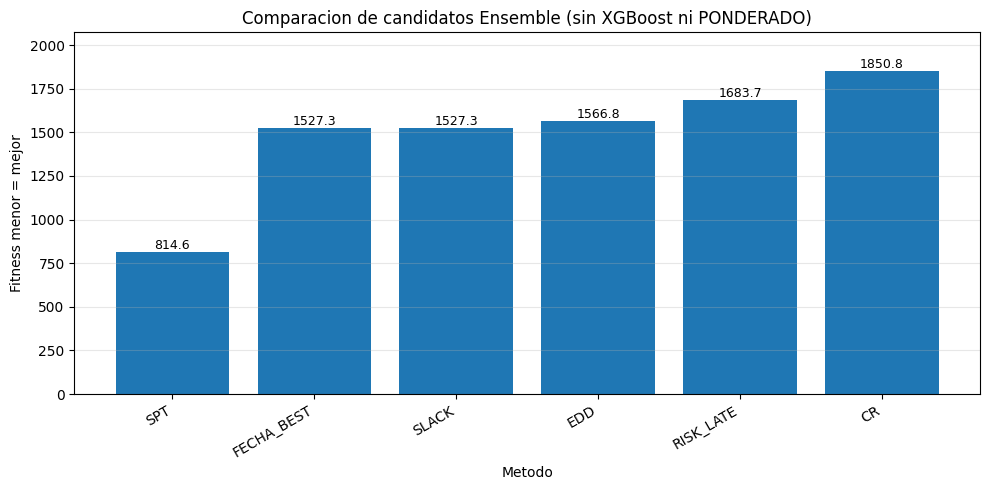


FASE 2: Entrenando XGBoost para estimar la secuencia de ordenes...
Las duraciones son fijas por formula CCP; XGBoost no estima tiempos.

Pesos de componentes para XGBoost (suma=1.0):
  EDD         :   0.00 (  0.0%)
  CR          :   0.00 (  0.0%)
  SLACK       :   0.85 ( 85.0%)
  RISK_LATE   :   0.00 (  0.0%)
  SPT         :   0.15 ( 15.0%)

Importancias de features en XGBoost de prioridad:
               feature  importance
2  dias_hasta_deadline    0.516854
0    deadline_work_min    0.398854
6            slack_min    0.077757
1             work_min    0.003424
5                   cr    0.002755
8            risk_late    0.000201
4        N_OPERACIONES    0.000064
3             CANTIDAD    0.000058
7    hist_late_rate_pn    0.000031

Evaluacion completa (con XGBoost)...
XGBOOST              fitness= 1538.5219 tardy=2172 makespan_d=  242.1
PONDERADO            fitness= 1564.7877 tardy=2171 makespan_d=  243.6
FECHA_BEST           fitness= 1527.2769 tardy=2196 makespan_d=  224.8
SPT    

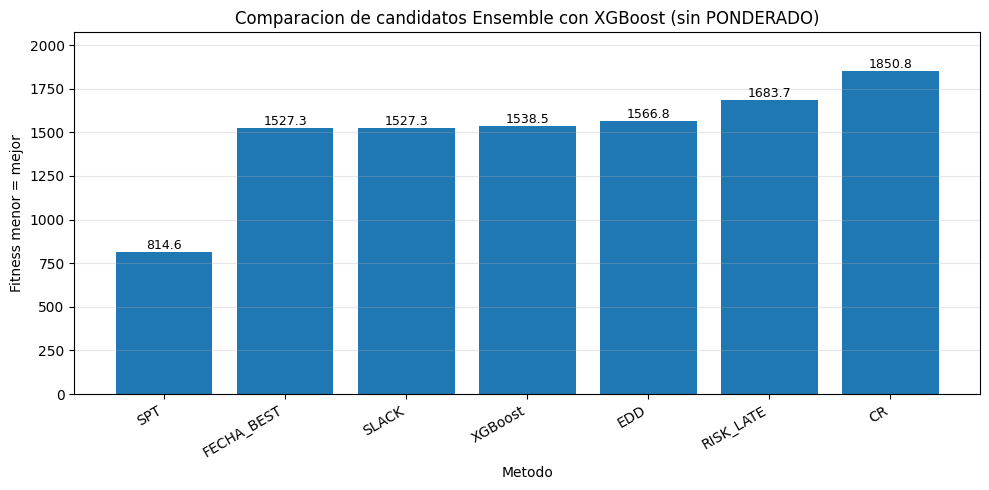


METODO PARA ARTEFACTOS Y METRICAS: XGBOOST
MEJOR CANDIDATO EN LA COMPARATIVA: SPT

Fitness XGBoost: 1538.5219
Metodo para artefactos: XGBOOST
Tipo de duracion: CCP_formula_fija
Formula duracion: (TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE
Mejor candidato en comparativa: SPT
Tiempo ejecucion Ensemble: 0.02 min

--- Pesos configurados para XGBoost ---
  Componente fecha seleccionada: SLACK
  EDD         : 0.0000
  CR          : 0.0000
  SLACK       : 0.8500
  RISK_LATE   : 0.0000
  SPT         : 0.1500
Metricas XGBoost usadas para archivos y graficas operativas:
  makespan_min                : 348679.7819763384
  makespan_days               : 242.13873748356835
  tardy_orders                : 2172
  due_orders                  : 2328
  on_time_rate                : 0.06701030927835051
  workload_hours              : 94627.933895521
  on_time_workload_hours      : 4123.610087971979
  on_time_workload_rate       : 0.04357709101548037
  total_late_min    

,metodo,makespan_min,makespan_days,tardy_orders,due_orders,on_time_rate,workload_hours,on_time_workload_hours,on_time_workload_rate,total_late_min,max_late_min,total_late_days,max_late_days,utilization,n_ops_scheduled,n_active_res,missing_ops,fitness,elapsed_s,elapsed_min
0,SPT,362632.091448,251.827841,1247,2328,0.464347,94618.197262,17706.057314,0.187132,1.183888e+08,361013.856154,82214.412089,250.704067,0.111030,10641,141,0,814.570492,0.95,0.02
1,FECHA_BEST,323697.832420,224.790161,2196,2328,0.056701,94557.395563,5468.745664,0.057835,2.683560e+08,191809.867055,186358.347081,133.201297,0.123429,10641,142,0,1527.276867,0.92,0.02
2,SLACK,323697.832420,224.790161,2196,2328,0.056701,94557.395563,5468.745664,0.057835,2.683560e+08,191809.867055,186358.347081,133.201297,0.123429,10641,142,0,1527.276867,1.02,0.02
3,XGBOOST,348679.781976,242.138737,2172,2328,0.067010,94627.933896,4123.610088,0.043577,2.746210e+08,217567.456614,190709.028152,151.088512,0.116310,10641,140,0,1538.521899,0.87,0.01
4,PONDERADO,350840.925089,243.639531,2171,2328,0.067440,94623.039602,4120.914302,0.043551,2.848833e+08,224092.481768,197835.623166,155.619779,0.115587,10641,140,0,1564.787699,0.89,0.01
5,EDD,353881.245140,245.750865,2211,2328,0.050258,94528.883040,4051.888329,0.042864,2.801575e+08,208772.342749,194553.807730,144.980794,0.114480,10641,140,0,1566.822323,0.97,0.02
6,RISK_LATE,338599.502158,235.138543,2228,2328,0.042955,94609.235808,5295.907888,0.055977,3.228529e+08,275822.030609,224203.402301,191.543077,0.118899,10641,141,0,1683.651994,1.05,0.02
7,CR,337297.677301,234.234498,2237,2328,0.039089,94599.874627,6264.973337,0.066226,3.866056e+08,315620.506713,268476.126418,219.180907,0.118506,10641,142,0,1850.800378,1.00,0.02


In [12]:
(
    best_chrom,
    best_score,
    best_met,
    logdf,
    pre_metricas,
    pre_best_name,
    ensemble_order_operations,
    prioridades_df,
    duraciones_operacion_df,
    xgboost_importancia_df,
    componente_fecha_seleccionado,
) = ejecutar_ensemble()

# Alias historicos: desde esta celda contienen siempre la solucion XGBoost.
print("\nFitness XGBoost:", round(best_score, 4))
print("Metodo para artefactos:", best_met.get("metodo_artefactos"))
print("Tipo de duracion:", best_met.get("tipo_duracion"))
print("Formula duracion:", best_met.get("formula_duracion"))
print("Mejor candidato en comparativa:", best_met.get("metodo_mejor_fitness"))
print("Tiempo ejecucion Ensemble:", f"{best_met.get('tiempo_ejecucion_ensemble_min', 0.0):.2f} min")

# Mostrar pesos configurados para XGBoost
print("\n--- Pesos configurados para XGBoost ---")
print("  Componente fecha seleccionada:", componente_fecha_seleccionado)
for nombre, peso in RANK_WEIGHTS.items():
    print(f"  {nombre:12s}: {peso:.4f}")

print("Metricas XGBoost usadas para archivos y graficas operativas:")
for k, v in best_met.items():
    print(f"  {k:28s}: {v}")

# Mostrar resultados de la pre-comparativa (sin XGBoost)
print("\n--- Pre-comparativa (candidatos sin XGBoost) ---")
print("Mejor candidato:", pre_best_name)
for nombre, met in pre_metricas.items():
    print(f"  {nombre:20s} fitness={met['fitness']:10.4f} tardy={met['tardy_orders']:3d} makespan_d={met['makespan_days']:7.1f}")

log_path = OUTPUT_DIR / "ens_log.csv"
logdf.to_csv(log_path, sep=";", index=False)

prioridades_path = OUTPUT_DIR / "ens_prioridades.csv"
prioridades_df.to_csv(prioridades_path, sep=";", index=False)

duraciones_path = OUTPUT_DIR / "ens_duraciones_fijas_operacion.csv"
duraciones_operacion_df.to_csv(duraciones_path, sep=";", index=False)

xgboost_metricas_path = OUTPUT_DIR / "ens_xgboost_metricas.csv"
pd.DataFrame([best_met]).to_csv(xgboost_metricas_path, sep=";", index=False)

if len(xgboost_importancia_df):
    importancia_path = OUTPUT_DIR / "ens_xgboost_feature_importance.csv"
    xgboost_importancia_df.to_csv(importancia_path, sep=";", index=False)
    print("Importancias XGBoost guardadas en:", importancia_path)

print("\nLog guardado en:", log_path)
print("Prioridades guardadas en:", prioridades_path)
print("Duraciones fijas guardadas en:", duraciones_path)
print("Metricas XGBoost guardadas en:", xgboost_metricas_path)
logdf



## 12. Metricas y comparacion contra heuristicas de referencia

In [13]:
# Usar pre_metricas (sin XGBoost) para la comparativa de heuristicas
comparativa = pd.DataFrame([
    {
        "metodo": nombre,
        **{k: v for k, v in met.items() if k not in ["metodo"]},
    }
    for nombre, met in pre_metricas.items()
]).sort_values("fitness").reset_index(drop=True)

cols = [
    "metodo", "fitness", "makespan_days", "tardy_orders", "due_orders", "on_time_rate",
    "workload_hours", "on_time_workload_hours", "on_time_workload_rate", "total_late_days",
    "max_late_days", "utilization", "n_ops_scheduled", "n_active_res", "missing_ops",
]
comparativa = comparativa[cols]
comparativa_path = OUTPUT_DIR / "ens_comparativa_metricas.csv"
comparativa.to_csv(comparativa_path, sep=";", index=False)
print("Comparativa guardada en:", comparativa_path)
comparativa

Comparativa guardada en: /opt/projects/tfm/algoritmos/output/ens_comparativa_metricas.csv


,metodo,fitness,makespan_days,tardy_orders,due_orders,on_time_rate,workload_hours,on_time_workload_hours,on_time_workload_rate,total_late_days,max_late_days,utilization,n_ops_scheduled,n_active_res,missing_ops
0,SPT,814.570492,251.827841,1247,2328,0.464347,94618.197262,17706.057314,0.187132,82214.412089,250.704067,0.111030,10641,141,0
1,FECHA_BEST,1527.276867,224.790161,2196,2328,0.056701,94557.395563,5468.745664,0.057835,186358.347081,133.201297,0.123429,10641,142,0
2,SLACK,1527.276867,224.790161,2196,2328,0.056701,94557.395563,5468.745664,0.057835,186358.347081,133.201297,0.123429,10641,142,0
3,PONDERADO,1564.787699,243.639531,2171,2328,0.067440,94623.039602,4120.914302,0.043551,197835.623166,155.619779,0.115587,10641,140,0
4,EDD,1566.822323,245.750865,2211,2328,0.050258,94528.883040,4051.888329,0.042864,194553.807730,144.980794,0.114480,10641,140,0
5,RISK_LATE,1683.651994,235.138543,2228,2328,0.042955,94609.235808,5295.907888,0.055977,224203.402301,191.543077,0.118899,10641,141,0
6,CR,1850.800378,234.234498,2237,2328,0.039089,94599.874627,6264.973337,0.066226,268476.126418,219.180907,0.118506,10641,142,0


## 13. Exportacion con estructura equivalente a LPA_GAM/LPA_GSM

In [14]:
def fmt_ts(ts):
    ts = pd.Timestamp(ts).round("s")
    return ts.strftime("%Y-%m-%d %H:%M:%S.") + "000"

best_sch, best_of, _, best_missing = decode_schedule(best_chrom, ensemble_order_operations, recursos_por_grupo)

export_rows = []
for s in best_sch:
    duracion_total = max(0.0, float(s["t_end"]) - float(s["t_start"]))
    segmentos = list(iterar_segmentos_laborales(s["t_start"], s["t_end"]))
    if not segmentos:
        ts = fecha_plan_desde_minutos_laborales(s["t_start"], como_fin=False)
        segmentos = [(ts, ts, 0.0)]

    for seg_inicio, seg_fin, seg_duracion in segmentos:
        factor = seg_duracion / duracion_total if duracion_total else 1.0
        export_rows.append({
            "ORDEN": s["ORDEN"],
            "OPERACION": int(s["OPERACION"]),
            "RECURSO": str(s["RECURSO"]),
            "PARTNUMBER": str(s["PARTNUMBER"]),
            "CANTIDAD": float(s["CANTIDAD"]),
            "COMIENZO_OPERACION": fmt_ts(seg_inicio),
            "FIN_OPERACION": fmt_ts(seg_fin),
            "TIEMPO_PREPARACION": round(float(s["TIEMPO_PREPARACION"]) * factor, 3),
            "TIEMPO_PROCESO": round(float(s["TIEMPO_PROCESO"]) * factor, 3),
            "GRUPO_RECURSO": str(s["GRUPO_RECURSO"]),
            "MULTIPLICIDAD": int(s["MULTIPLICIDAD"]),
            "DURACION_CCP": round(float(s["DURACION_CCP"]) * factor, 3),
            "FECHA_CALCULO_PLAN": fmt_ts(PLAN_START),
        })

out_df = pd.DataFrame(export_rows)
lpa_columns = [
    "ORDEN", "OPERACION", "RECURSO", "PARTNUMBER", "CANTIDAD", "COMIENZO_OPERACION", "FIN_OPERACION",
    "TIEMPO_PREPARACION", "TIEMPO_PROCESO", "GRUPO_RECURSO", "MULTIPLICIDAD", "DURACION_CCP", "FECHA_CALCULO_PLAN",
]
out_df = out_df[lpa_columns]

csv_path = OUTPUT_DIR / "ens_resultados.csv"
out_df.to_csv(csv_path, sep=";", index=False)

print("Resultado guardado en:", csv_path)
print("Filas exportadas:", len(out_df))
print("Operaciones sin planificar:", len(best_missing))
out_df.head()


Resultado guardado en: /opt/projects/tfm/algoritmos/output/ens_resultados.csv
Filas exportadas: 14533
Operaciones sin planificar: 0


,ORDEN,OPERACION,RECURSO,PARTNUMBER,CANTIDAD,COMIENZO_OPERACION,FIN_OPERACION,TIEMPO_PREPARACION,TIEMPO_PROCESO,GRUPO_RECURSO,MULTIPLICIDAD,DURACION_CCP,FECHA_CALCULO_PLAN
0,ORDEN_11055,900020,RECURSO_117,PARTNUMBER_5467,8.0,2026-05-19 00:00:00.000,2026-05-19 02:53:05.000,0.0,173.091,GRUPO_RECURSO_2,1,173.091,2026-05-19 00:00:00.000
1,ORDEN_1087,800020,RECURSO_147,PARTNUMBER_909,8.0,2026-05-19 00:00:00.000,2026-05-19 01:33:20.000,0.0,93.333,GRUPO_RECURSO_21,1,93.333,2026-05-19 00:00:00.000
2,ORDEN_1087,800030,RECURSO_147,PARTNUMBER_909,8.0,2026-05-19 01:33:20.000,2026-05-19 02:53:20.000,0.0,80.000,GRUPO_RECURSO_21,1,80.000,2026-05-19 00:00:00.000
3,ORDEN_1087,800040,RECURSO_187,PARTNUMBER_909,8.0,2026-05-19 02:53:20.000,2026-05-19 03:30:53.000,0.0,37.553,GRUPO_RECURSO_1,1,37.553,2026-05-19 00:00:00.000
4,ORDEN_2651,900020,RECURSO_142,PARTNUMBER_1551,4.0,2026-05-19 00:00:00.000,2026-05-19 00:47:03.000,0.0,47.049,GRUPO_RECURSO_8,1,47.049,2026-05-19 00:00:00.000


## 14. Validacion de restricciones duras

In [15]:
def validar_schedule(out_df, recursos_por_grupo, ensemble_order_operations):
    errores = []
    df = out_df.copy()
    df["COMIENZO_OPERACION_DT"] = pd.to_datetime(df["COMIENZO_OPERACION"], errors="coerce")
    df["FIN_OPERACION_DT"] = pd.to_datetime(df["FIN_OPERACION"], errors="coerce")

    # 1) No solape por máquina.
    overlaps = 0
    for recurso, sub in df.sort_values(["RECURSO", "COMIENZO_OPERACION_DT"]).groupby("RECURSO"):
        prev_end = None
        prev_order = None
        for _, r in sub.iterrows():
            if prev_end is not None and r["COMIENZO_OPERACION_DT"] < prev_end:
                overlaps += 1
                if len(errores) < 20:
                    errores.append({"tipo": "solape_recurso", "RECURSO": recurso, "ORDEN": r["ORDEN"], "prev_ORDEN": prev_order})
            prev_end = r["FIN_OPERACION_DT"]
            prev_order = r["ORDEN"]

    # 2) Precedencia dentro de cada orden.
    precedence_errors = 0
    for orden, sub in df.sort_values(["ORDEN", "COMIENZO_OPERACION_DT"]).groupby("ORDEN"):
        prev_end = None
        for _, r in sub.iterrows():
            if prev_end is not None and r["COMIENZO_OPERACION_DT"] < prev_end:
                precedence_errors += 1
                if len(errores) < 20:
                    errores.append({"tipo": "precedencia_orden", "ORDEN": orden, "OPERACION": r["OPERACION"]})
            prev_end = r["FIN_OPERACION_DT"]

    # 3) Recurso pertenece al grupo.
    invalid_group = 0
    for _, r in df.iterrows():
        if str(r["RECURSO"]) not in set(recursos_por_grupo.get(str(r["GRUPO_RECURSO"]), [])):
            invalid_group += 1
            if len(errores) < 20:
                errores.append({"tipo": "recurso_fuera_de_grupo", "RECURSO": r["RECURSO"], "GRUPO_RECURSO": r["GRUPO_RECURSO"]})

    # 4) Cada tramo exportado cae dentro del calendario laboral configurado.
    calendar_errors = 0
    for _, r in df.iterrows():
        inicio = r["COMIENZO_OPERACION_DT"]
        fin = r["FIN_OPERACION_DT"]
        if pd.isna(inicio) or pd.isna(fin) or fin < inicio:
            calendar_errors += 1
            if len(errores) < 20:
                errores.append({"tipo": "calendario_laboral", "ORDEN": r["ORDEN"], "OPERACION": r["OPERACION"]})
            continue
        if fin == inicio:
            continue
        turno_inicio = inicio_turno_dia(inicio)
        turno_fin = fin_turno_dia(inicio)
        if not es_dia_laborable(inicio) or inicio < turno_inicio or fin > turno_fin:
            calendar_errors += 1
            if len(errores) < 20:
                errores.append({"tipo": "calendario_laboral", "ORDEN": r["ORDEN"], "OPERACION": r["OPERACION"]})

    expected_ops = sum(v["n_ops"] for v in ensemble_order_operations.values())
    planned_ops = len(df[["ORDEN", "OPERACION"]].drop_duplicates())
    return {
        "segmentos_plan": len(df),
        "operaciones_planificadas_unicas": planned_ops,
        "operaciones_esperadas": expected_ops,
        "operaciones_faltantes": expected_ops - planned_ops,
        "solapes_recurso": overlaps,
        "errores_precedencia": precedence_errors,
        "recurso_fuera_de_grupo": invalid_group,
        "errores_calendario_laboral": calendar_errors,
        "valido": overlaps == 0 and precedence_errors == 0 and invalid_group == 0 and calendar_errors == 0 and expected_ops == planned_ops,
        "muestra_errores": errores,
    }

validation = validar_schedule(out_df, recursos_por_grupo, ensemble_order_operations)
validation_path = OUTPUT_DIR / "ens_validacion_schedule.json"
with open(validation_path, "w", encoding="utf-8") as f:
    json.dump(validation, f, ensure_ascii=False, indent=2, default=str)

print(json.dumps(validation, ensure_ascii=False, indent=2, default=str))
print("Validación guardada en:", validation_path)

{
  "segmentos_plan": 14533,
  "operaciones_planificadas_unicas": 10641,
  "operaciones_esperadas": 10641,
  "operaciones_faltantes": 0,
  "solapes_recurso": 0,
  "errores_precedencia": 0,
  "recurso_fuera_de_grupo": 0,
  "errores_calendario_laboral": 0,
  "valido": true,
  "muestra_errores": []
}
Validación guardada en: /opt/projects/tfm/algoritmos/output/ens_validacion_schedule.json


### Candidatos evaluados:

Este notebook prueba **6 estrategias diferentes** de ordenamiento de ordenes. Todas usan las mismas duraciones fijas calculadas desde CCP:

```text
(TIEMPO_FIJO_MIN + TIEMPO_VARIABLE_MIN * CANTIDAD / MULTIPLICIDAD) * 100 / OEE
```

0. **XGBOOST** (Principal): Modelo de Machine Learning XGBoost que estima un score de prioridad/secuencia para cada orden basandose en:
   - Plazo de entrega y tiempo disponible
   - Carga fija de trabajo calculada desde CCP
   - Cantidad y complejidad de la orden (N_OPERACIONES)
   - Riesgo historico de atraso
   - Holgura disponible (Slack)
   - Ratio critico (Critical Ratio)

   XGBoost **no estima duraciones**. Solo aprende un score para ordenar las ordenes. Menor score implica mayor prioridad.

1. **PONDERADO**: Combinacion ponderada de 5 heuristicas clasicas (baseline para comparacion):
   - EDD (Earliest Due Date): 25% - Prioriza fechas de entrega proximas
   - CR (Critical Ratio): 25% - Ratio entre tiempo disponible y trabajo pendiente fijo
   - SLACK: 20% - Holgura disponible
   - RISK_LATE: 20% - Probabilidad heuristica/historica de atraso
   - SPT: 10% - Ordenes con menor carga fija primero

2. **EDD**: Ordena por fecha de entrega mas proxima.

3. **SPT**: Ordena por carga fija CCP mas corta.

4. **CR**: `CR = tiempo hasta fecha limite / trabajo fijo pendiente`. Valores bajos indican urgencia.

5. **SLACK**: `Slack = tiempo disponible - trabajo fijo pendiente`. Negativo = en riesgo.

### Resultado en esta ejecucion:

El **metodo seleccionado para exportar resultados, Gantt, validacion y metricas detalladas** es siempre **XGBOOST**. El notebook:
1. Calcula duraciones fijas desde CCP
2. Entrena XGBoost para estimar la secuencia de ordenes
3. Compara XGBoost con 5 heuristicas clasicas en `ens_log.csv` y `ens_comparativa_metricas.csv`
4. Usa XGBoost como solucion operativa aunque otra heuristica tenga menor fitness en la comparativa
5. Exporta las importancias de features de XGBoost para analisis

Nota: ens_comparacion_candidatos.png se genero con XGBoost y sin PONDERADO
Gantt XGBoost guardado en: /opt/projects/tfm/algoritmos/output/ens_gantt.png


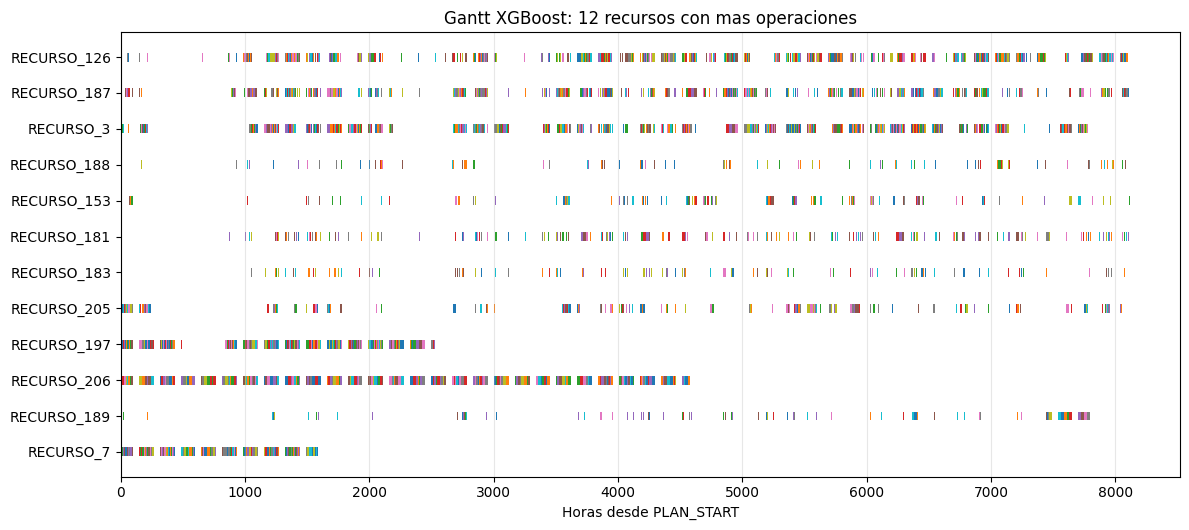

Gantt XGBoost de maquinas extremas guardado en: /opt/projects/tfm/algoritmos/output/ens_gantt_extremos.png


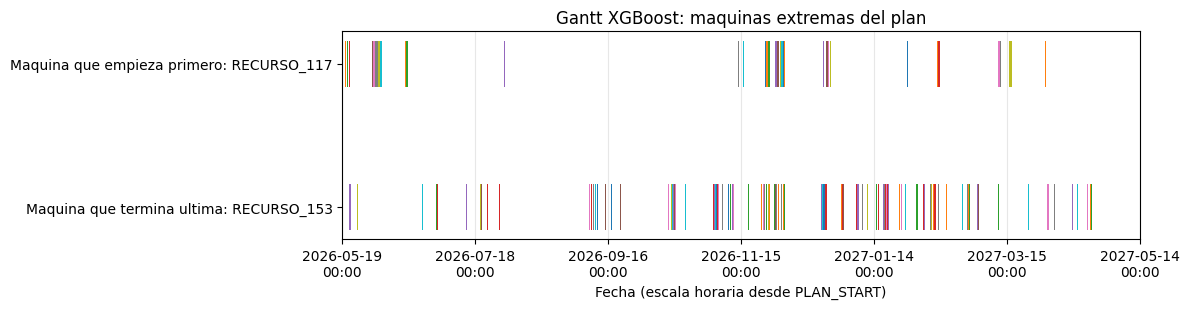

In [16]:
if len(logdf):
    # La grafica se genera en ejecutar_ensemble: primero sin XGBoost y luego con XGBoost.
    print("Nota: ens_comparacion_candidatos.png se genero con XGBoost y sin PONDERADO")

# Gantt de los recursos mas cargados.
if len(out_df):
    gantt_df = out_df.copy()
    gantt_df["RECURSO"] = gantt_df["RECURSO"].astype(str)
    gantt_df["COMIENZO_OPERACION_DT"] = pd.to_datetime(gantt_df["COMIENZO_OPERACION"])
    gantt_df["FIN_OPERACION_DT"] = pd.to_datetime(gantt_df["FIN_OPERACION"])

    def configurar_eje_horas_como_fechas(ax, inicio_plan, min_h, max_h):
        rango_h = max(float(max_h) - float(min_h), 1.0)
        pasos_h = [1, 2, 4, 8, 12, 24, 48, 72, 168, 336, 720, 1440]
        paso_h = next((p for p in pasos_h if rango_h / p <= 8), pasos_h[-1])
        tick_inicio = math.floor(float(min_h) / paso_h) * paso_h
        ticks = np.arange(tick_inicio, float(max_h) + paso_h, paso_h)
        ax.set_xticks(ticks)
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda h, _pos: (inicio_plan + pd.to_timedelta(float(h), unit="h")).strftime("%Y-%m-%d\n%H:%M")
            )
        )

    top_recursos = gantt_df.groupby("RECURSO").size().sort_values(ascending=False).head(12).index.tolist()
    sub = gantt_df[gantt_df["RECURSO"].isin(top_recursos)].copy()

    fig, ax = plt.subplots(figsize=(12, max(5, len(top_recursos) * 0.45)))
    y_map = {r: i for i, r in enumerate(reversed(top_recursos))}
    for _, row in sub.iterrows():
        y = y_map[row["RECURSO"]]
        start_h = (row["COMIENZO_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
        dur_h = (row["FIN_OPERACION_DT"] - row["COMIENZO_OPERACION_DT"]).total_seconds() / 3600.0
        ax.barh(y, max(dur_h, 0.01), left=start_h, height=0.25)
    ax.set_yticks(list(range(len(top_recursos))))
    ax.set_yticklabels(reversed(top_recursos))
    ax.set_xlabel("Horas desde PLAN_START")
    ax.set_title("Gantt XGBoost: 12 recursos con mas operaciones")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    gantt_path = OUTPUT_DIR / "ens_gantt.png"
    plt.savefig(gantt_path, dpi=150, bbox_inches="tight")
    print("Gantt XGBoost guardado en:", gantt_path)
    plt.show()

    # Gantt de dos filas: maquina que empieza primero y maquina que termina ultima.
    recurso_primero = gantt_df.loc[gantt_df["COMIENZO_OPERACION_DT"].idxmin(), "RECURSO"]
    recurso_ultimo = gantt_df.loc[gantt_df["FIN_OPERACION_DT"].idxmax(), "RECURSO"]
    recursos_extremos = [
        ("Maquina que empieza primero", recurso_primero),
        ("Maquina que termina ultima", recurso_ultimo),
    ]

    fig, ax = plt.subplots(figsize=(12, 3.2))
    min_h, max_h = math.inf, -math.inf
    for y, (_rol, recurso) in enumerate(recursos_extremos):
        sub_extremo = gantt_df[gantt_df["RECURSO"] == recurso].sort_values("COMIENZO_OPERACION_DT")
        for _, row in sub_extremo.iterrows():
            start_h = (row["COMIENZO_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
            end_h = (row["FIN_OPERACION_DT"] - PLAN_START).total_seconds() / 3600.0
            dur_h = end_h - start_h
            min_h = min(min_h, start_h)
            max_h = max(max_h, end_h)
            ax.barh(y, max(dur_h, 0.01), left=start_h, height=0.32)

    ax.set_yticks(list(range(len(recursos_extremos))))
    ax.set_yticklabels([f"{rol}: {recurso}" for rol, recurso in recursos_extremos])
    ax.invert_yaxis()
    configurar_eje_horas_como_fechas(ax, PLAN_START, min_h, max_h)
    ax.set_xlabel("Fecha (escala horaria desde PLAN_START)")
    ax.set_title("Gantt XGBoost: maquinas extremas del plan")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    gantt_extremos_path = OUTPUT_DIR / "ens_gantt_extremos.png"
    plt.savefig(gantt_extremos_path, dpi=150, bbox_inches="tight")
    print("Gantt XGBoost de maquinas extremas guardado en:", gantt_extremos_path)
    plt.show()

## Comparativa de heurísticas: por qué SPT es el mejor

### Definiciones de cada regla de prioridad

**SPT (Shortest Processing Time)** — Ordena por carga total más corta primero. Las órdenes que se terminan rápido van al principio.

```python
def spt_permutation(order_ops):
    def total_proc(idx):
        return sum(min(a["dur_total"] for a in op["alternativas"]) for op in order_ops[idx]["ops"])
    return sorted(order_ops.keys(), key=lambda idx: (total_proc(idx), idx))
```

**SLACK (Holgura)** — Ordena por holgura más pequeña primero. `Slack = tiempo disponible - trabajo pendiente`. Las órdenes con menos margen van al principio.

```python
def slack_permutation(order_ops):
    def order_slack(idx):
        work = sum(min(a["dur_total"] for a in op["alternativas"]) for op in order_ops[idx]["ops"])
        due = order_ops[idx].get("deadline_work_min", math.inf)
        return due - work
    return sorted(order_ops.keys(), key=lambda idx: (order_slack(idx), idx))
```

**EDD (Earliest Due Date)** — Ordena por fecha de entrega más próxima. Las órdenes con deadline más cercano van al principio.

```python
def edd_permutation(order_ops):
    return sorted(order_ops.keys(), key=lambda idx: (
        pd.Timestamp(order_ops[idx]["deadline"]), idx))
```

**CR (Critical Ratio)** — Ordena por ratio crítico más bajo. `CR = tiempo hasta deadline / trabajo pendiente`. Un CR < 1 significa que la orden no puede terminar a tiempo con el trabajo pendiente.

```python
def cr_permutation(order_ops):
    def remaining_work(idx):
        return sum(min(a["dur_total"] for a in op["alternativas"]) for op in order_ops[idx]["ops"])
    cr = time_to_due_min / work if math.isfinite(time_to_due_min) else math.inf
```

### Resultados reales de la comparativa

| Métrica | SPT | SLACK | EDD | PONDERADO | XGBOOST | CR |
|---|---|---|---|---|---|---|
| **Fitness** | **1186** | 2589 | 2679 | 2816 | 2860 | 3060 |
| **Makespan (días)** | **441** | 476 | 502 | 490 | 501 | 452 |
| **Tardanzas máximas** | **435** | 323 | 351 | 392 | 403 | **441** |
| **% en fecha** | **39.4%** | 3.8% | 4.0% | 3.1% | 3.3% | 3.0% |
| **Carga en fecha** | **11.3%** | 2.9% | 2.8% | 2.7% | 2.5% | 3.9% |

### Por qué SPT es el mejor

SPT minimiza el makespan y las tardanzas máximas simultáneamente porque:

1. **Termina órdenes rápidas primero** → libera recursos más rápido → el makespan global se reduce (441 vs 502 de EDD)
2. **Menos tardanzas máximas** (435 días vs 392-441 de los demás) porque al terminar órdenes cortas antes, no acumula retraso en cascada
3. **Más órdenes en fecha** (39.4% vs ~3% del resto) porque las órdenes rápidas tienen más probabilidad de cerrar antes del deadline

### Por qué los otros fallan

- **EDD**: Prioriza deadlines lejanos que no pueden cumplirse → acumula retraso
- **SLACK/CR**: Priorizan urgencia relativa pero ignoran el impacto global en el makespan
- **PONDERADO/XGBOOST**: Combinan señales contradictorias que se cancelan entre sí

**En resumen:** SPT es la heurística clásica que mejor funciona cuando el objetivo es minimizar tardanzas y makespan simultáneamente. Es un resultado conocido en la literatura de scheduling (regla "Shortest Processing Time first" es óptima para minimizar número de órdenes tardías).

## Conclusion tecnica

La planificacion XGBoost exportada por este notebook es valida si la celda de validacion devuelve `valido = True`.

Artefactos principales:

- `ens_resultados.csv`: plan XGBoost exportado con formato equivalente a LPA.
- `ens_xgboost_metricas.csv`: metricas globales de la planificacion XGBoost, pensado para comparar contra otros algoritmos.
- `ens_duraciones_fijas_operacion.csv`: auditoria de duraciones fijas calculadas desde CCP.
- `ens_comparativa_metricas.csv`: comparacion de candidatos Ensemble y heuristicas base.
- `ens_gantt.png`: Gantt XGBoost de los 12 recursos con mas operaciones.
- `ens_gantt_extremos.png`: Gantt XGBoost de la maquina que empieza primero y la que termina ultima.
- `ens_prioridades.csv`: tabla de features, rankings y score de prioridad por orden.
- `ens_metricas_por_orden.csv` y `ens_metricas_por_recurso.csv`: analisis detallado del plan XGBoost.

## 16. Analisis de prioridades y prediccion de tiempos

In [17]:
print("Top 20 prioridades Ensemble")
display(prioridades_df.head(20))

print("Importancias XGBoost para prioridad/secuencia")
display(xgboost_importancia_df.head(20))

print("Muestra de duraciones fijas CCP")
display(duraciones_operacion_df.head(20))

Top 20 prioridades Ensemble


,oidx,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,FECHA_PROVEEDOR,deadline_work_min,work_min,slack_min,cr,dias_hasta_deadline,hist_late_rate_pn,heuristic_late_risk,risk_late,rank_edd,rank_cr,rank_slack,rank_risk_late,rank_spt
0,0,ORDEN_7,PARTNUMBER_7,8.0,6,2026-06-15,27360.0,1353.654908,26006.345092,20.211946,19.0,1.000000,1.434360e-08,6.000000e-01,676.5,871.0,680.0,642.0,1065.0
1,1,ORDEN_25,PARTNUMBER_20,29.0,3,2026-08-12,87840.0,1598.686162,86241.313838,54.945118,61.0,0.250000,2.061154e-09,1.500000e-01,1991.0,1581.0,1999.0,1672.0,1212.0
2,2,ORDEN_57,PARTNUMBER_56,30.0,3,2026-06-20,34560.0,1691.089542,32868.910458,20.436529,24.0,0.666667,3.620953e-09,4.000000e-01,792.5,883.5,813.5,1318.5,1271.5
3,3,ORDEN_63,PARTNUMBER_61,20.0,4,2026-06-06,20160.0,1092.393434,19067.606566,18.454889,14.0,1.000000,1.775559e-06,6.000007e-01,545.0,808.0,571.0,521.0,875.0
4,4,ORDEN_71,PARTNUMBER_69,48.0,6,2026-06-16,28800.0,1256.404954,27543.595046,22.922546,20.0,1.000000,4.932122e-09,6.000000e-01,719.0,982.0,732.0,668.0,993.0
5,5,ORDEN_72,PARTNUMBER_70,16.0,5,2026-06-30,43200.0,7465.286171,35734.713829,5.786784,30.0,1.000000,8.270264e-03,6.033081e-01,1044.5,348.0,892.0,277.0,2181.0
6,6,ORDEN_73,PARTNUMBER_71,64.0,1,2026-06-27,41760.0,426.666667,41333.333333,97.875000,29.0,0.000000,2.061154e-09,8.244614e-10,941.5,1876.0,1015.0,2091.0,350.0
7,7,ORDEN_76,PARTNUMBER_74,12.0,2,2026-05-20,1440.0,2307.476456,-867.476456,0.624058,1.0,1.000000,5.928939e-01,8.371576e-01,60.5,68.0,74.0,56.0,1581.0
8,8,ORDEN_77,PARTNUMBER_75,34.0,6,2026-08-01,77760.0,888.032143,76871.967857,87.564398,54.0,1.000000,2.061154e-09,6.000000e-01,1770.5,1827.0,1794.0,933.0,751.0
9,9,ORDEN_78,PARTNUMBER_76,10.0,3,2026-05-25,5760.0,325.044123,5434.955877,17.720671,4.0,1.000000,2.243868e-02,6.089755e-01,140.0,789.0,217.0,252.0,237.0


Importancias XGBoost para prioridad/secuencia


,feature,importance
2,dias_hasta_deadline,0.516854
0,deadline_work_min,0.398854
6,slack_min,0.077757
1,work_min,0.003424
5,cr,0.002755
8,risk_late,0.000201
4,N_OPERACIONES,0.000064
3,CANTIDAD,0.000058
7,hist_late_rate_pn,0.000031


Muestra de duraciones fijas CCP


,oidx,ORDEN,PARTNUMBER,OPERACION,GRUPO_RECURSO,CCP_RECURSO,CANTIDAD,TIEMPO_FIJO_MIN,TIEMPO_VARIABLE_MIN,MULTIPLICIDAD,OEE,tiempo_proceso_sin_oee_min,duracion_base_sin_oee_min,duracion_fija_ccp_min,duracion_formula_min,diferencia_formula_min
0,0,ORDEN_7,PARTNUMBER_7,900020,GRUPO_RECURSO_104,RECURSO_76,8.0,30.0,104.00,1,74.34,832.000000,862.000000,1159.537261,1159.537261,0.000000e+00
1,0,ORDEN_7,PARTNUMBER_7,900030,GRUPO_RECURSO_43,RECURSO_8,8.0,1.0,1.00,1,85.00,8.000000,9.000000,10.588235,10.588235,0.000000e+00
2,0,ORDEN_7,PARTNUMBER_7,900040,GRUPO_RECURSO_43,RECURSO_9,8.0,5.0,9.00,1,85.00,72.000000,77.000000,90.588235,90.588235,0.000000e+00
3,0,ORDEN_7,PARTNUMBER_7,900050,GRUPO_RECURSO_24,RECURSO_24,8.0,5.0,1.00,1,85.00,8.000000,13.000000,15.294118,15.294118,0.000000e+00
4,0,ORDEN_7,PARTNUMBER_7,900060,GRUPO_RECURSO_11,RECURSO_11,8.0,5.0,1.00,1,85.00,8.000000,13.000000,15.294118,15.294118,0.000000e+00
5,0,ORDEN_7,PARTNUMBER_7,1300020,GRUPO_RECURSO_4,RECURSO_4,8.0,5.0,6.00,1,85.00,48.000000,53.000000,62.352941,62.352941,0.000000e+00
6,1,ORDEN_25,PARTNUMBER_20,1000020,GRUPO_RECURSO_14,RECURSO_55,29.0,30.0,20.33,1,85.74,589.570000,619.570000,722.614882,722.614882,0.000000e+00
7,1,ORDEN_25,PARTNUMBER_20,1000030,GRUPO_RECURSO_14,RECURSO_55,29.0,30.0,24.17,1,90.48,700.930000,730.930000,807.835986,807.835986,2.273737e-13
8,1,ORDEN_25,PARTNUMBER_20,1000040,GRUPO_RECURSO_43,RECURSO_126,29.0,0.0,2.00,1,85.00,58.000000,58.000000,68.235294,68.235294,0.000000e+00
9,2,ORDEN_57,PARTNUMBER_56,1000010,GRUPO_RECURSO_65,RECURSO_104,30.0,0.0,9.33,1,100.00,279.900000,279.900000,279.900000,279.900000,0.000000e+00


## 17. Analisis ampliado por orden y por recurso

In [18]:
# Metricas por orden.
workload_by_order_min = defaultdict(float)
for s in best_sch:
    workload_by_order_min[s["oidx"]] += max(0.0, s["t_end"] - s["t_start"])

order_rows = []
finish_by_order = {idx: finish for idx, finish in best_of.items()}
for idx, od in ensemble_order_operations.items():
    finish_min = finish_by_order.get(idx, math.inf)
    if math.isfinite(finish_min):
        finish_dt = fecha_plan_desde_minutos_laborales(finish_min)
    else:
        finish_dt = pd.NaT
    deadline = pd.Timestamp(od["deadline"]) if pd.notna(od["deadline"]) else pd.NaT
    deadline_work_min = od.get("deadline_work_min", math.inf)
    late_min = max(0.0, float(finish_min) - float(deadline_work_min)) if math.isfinite(finish_min) and math.isfinite(deadline_work_min) else math.inf
    order_rows.append({
        "ORDEN": od["orden"],
        "PARTNUMBER": od["pn"],
        "CANTIDAD": od["qty"],
        "N_OPERACIONES": od["n_ops"],
        "CARGA_TRABAJO_HORAS": workload_by_order_min.get(idx, 0.0) / 60.0,
        "FECHA_PROVEEDOR": deadline,
        "FIN_PLANIFICADO": finish_dt,
        "TARDANZA_MIN": late_min,
        "TARDANZA_DIAS": late_min / max(MINUTOS_TRABAJO_DIA, 1.0) if math.isfinite(late_min) else math.inf,
        "A_TIEMPO": bool(late_min <= 0),
    })

orden_metricas_df = pd.DataFrame(order_rows).sort_values(["A_TIEMPO", "TARDANZA_MIN"], ascending=[True, False])
orden_metricas_path = OUTPUT_DIR / "ens_metricas_por_orden.csv"
orden_metricas_df.to_csv(orden_metricas_path, sep=";", index=False)

ordenes_fuera_fecha_df = orden_metricas_df[~orden_metricas_df["A_TIEMPO"]].copy()
ordenes_fuera_fecha_path = OUTPUT_DIR / "ens_ordenes_fuera_fecha.csv"
ordenes_fuera_fecha_df.to_csv(ordenes_fuera_fecha_path, sep=";", index=False)

carga_total_horas = orden_metricas_df["CARGA_TRABAJO_HORAS"].sum()
carga_en_fecha_horas = orden_metricas_df.loc[orden_metricas_df["A_TIEMPO"], "CARGA_TRABAJO_HORAS"].sum()
ordenes_totales = len(orden_metricas_df)
ordenes_en_fecha = int(orden_metricas_df["A_TIEMPO"].sum())
metricas_cumplimiento_fechas_df = pd.DataFrame([{
    "ordenes_totales": ordenes_totales,
    "ordenes_en_fecha": ordenes_en_fecha,
    "ordenes_fuera_fecha": int(len(ordenes_fuera_fecha_df)),
    "porcentaje_ordenes_en_fecha": (ordenes_en_fecha / ordenes_totales * 100.0) if ordenes_totales else 0.0,
    "carga_total_horas": carga_total_horas,
    "carga_en_fecha_horas": carga_en_fecha_horas,
    "carga_fuera_fecha_horas": carga_total_horas - carga_en_fecha_horas,
    "porcentaje_carga_horas_en_fecha": (carga_en_fecha_horas / carga_total_horas * 100.0) if carga_total_horas else 0.0,
}])
metricas_cumplimiento_fechas_path = OUTPUT_DIR / "ens_metricas_cumplimiento_fechas.csv"
metricas_cumplimiento_fechas_df.to_csv(metricas_cumplimiento_fechas_path, sep=";", index=False)

print("Metricas por orden guardadas en:", orden_metricas_path)
print("Ordenes fuera de fecha guardadas en:", ordenes_fuera_fecha_path)
print("Metricas de cumplimiento de fechas guardadas en:", metricas_cumplimiento_fechas_path)
display(metricas_cumplimiento_fechas_df)
display(orden_metricas_df.head(20))
display(ordenes_fuera_fecha_df.head(20))

# Metricas por recurso.
res_df = out_df.copy()
res_df["COMIENZO_OPERACION_DT"] = pd.to_datetime(res_df["COMIENZO_OPERACION"])
res_df["FIN_OPERACION_DT"] = pd.to_datetime(res_df["FIN_OPERACION"])
res_df["DURACION_MIN"] = (res_df["FIN_OPERACION_DT"] - res_df["COMIENZO_OPERACION_DT"]).dt.total_seconds() / 60.0
makespan_min = best_met["makespan_min"]
recurso_metricas_df = (
    res_df.groupby(["GRUPO_RECURSO", "RECURSO"], as_index=False)
    .agg(
        operaciones=("ORDEN", "count"),
        carga_min=("DURACION_MIN", "sum"),
        comienzo=("COMIENZO_OPERACION_DT", "min"),
        fin=("FIN_OPERACION_DT", "max"),
    )
)
recurso_metricas_df["utilizacion_sobre_makespan"] = recurso_metricas_df["carga_min"] / makespan_min
recurso_metricas_df = recurso_metricas_df.sort_values("carga_min", ascending=False)
recurso_metricas_path = OUTPUT_DIR / "ens_metricas_por_recurso.csv"
recurso_metricas_df.to_csv(recurso_metricas_path, sep=";", index=False)
print("Metricas por recurso guardadas en:", recurso_metricas_path)
display(recurso_metricas_df.head(20))


Metricas por orden guardadas en: /opt/projects/tfm/algoritmos/output/ens_metricas_por_orden.csv
Ordenes fuera de fecha guardadas en: /opt/projects/tfm/algoritmos/output/ens_ordenes_fuera_fecha.csv
Metricas de cumplimiento de fechas guardadas en: /opt/projects/tfm/algoritmos/output/ens_metricas_cumplimiento_fechas.csv


,ordenes_totales,ordenes_en_fecha,ordenes_fuera_fecha,porcentaje_ordenes_en_fecha,carga_total_horas,carga_en_fecha_horas,carga_fuera_fecha_horas,porcentaje_carga_horas_en_fecha
0,2328,156,2172,6.701031,94627.933896,4123.610088,90504.323808,4.357709


,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,CARGA_TRABAJO_HORAS,FECHA_PROVEEDOR,FIN_PLANIFICADO,TARDANZA_MIN,TARDANZA_DIAS,A_TIEMPO
157,ORDEN_1511,PARTNUMBER_1233,12.0,14,152.948719,2026-09-02,2027-04-01 02:07:27.396826368,217567.456614,151.088512,False
1543,ORDEN_9742,PARTNUMBER_5090,32.0,6,119.209273,2026-08-16,2027-03-16 00:50:28.907040042,217490.481784,151.035057,False
799,ORDEN_5849,PARTNUMBER_1567,160.0,7,167.847487,2026-08-30,2027-03-26 09:47:30.038339129,215147.500639,149.407987,False
2114,ORDEN_13600,PARTNUMBER_650,42.0,8,122.550224,2026-08-15,2027-03-12 07:08:07.730569457,214988.128843,149.297312,False
2105,ORDEN_13552,PARTNUMBER_3736,480.0,3,85.600193,2026-08-08,2027-03-04 03:26:09.111037632,213326.151851,148.143161,False
1565,ORDEN_9802,PARTNUMBER_1424,94.0,6,27.926607,2026-08-04,2027-02-25 20:48:22.774323642,212928.379572,147.866930,False
60,ORDEN_520,PARTNUMBER_455,60.0,6,121.290577,2026-08-17,2027-03-10 20:12:22.554098868,212892.375902,147.841928,False
1234,ORDEN_7933,PARTNUMBER_4514,40.0,6,64.160619,2026-08-08,2027-03-03 18:14:59.934567042,212774.998909,147.760416,False
77,ORDEN_765,PARTNUMBER_658,10.0,7,118.005543,2026-08-15,2027-03-10 13:46:22.554098868,212506.375902,147.573872,False
1556,ORDEN_9765,PARTNUMBER_1424,58.0,6,17.409450,2026-08-04,2027-02-25 11:26:01.597853046,212366.026631,147.476407,False


,ORDEN,PARTNUMBER,CANTIDAD,N_OPERACIONES,CARGA_TRABAJO_HORAS,FECHA_PROVEEDOR,FIN_PLANIFICADO,TARDANZA_MIN,TARDANZA_DIAS,A_TIEMPO
157,ORDEN_1511,PARTNUMBER_1233,12.0,14,152.948719,2026-09-02,2027-04-01 02:07:27.396826368,217567.456614,151.088512,False
1543,ORDEN_9742,PARTNUMBER_5090,32.0,6,119.209273,2026-08-16,2027-03-16 00:50:28.907040042,217490.481784,151.035057,False
799,ORDEN_5849,PARTNUMBER_1567,160.0,7,167.847487,2026-08-30,2027-03-26 09:47:30.038339129,215147.500639,149.407987,False
2114,ORDEN_13600,PARTNUMBER_650,42.0,8,122.550224,2026-08-15,2027-03-12 07:08:07.730569457,214988.128843,149.297312,False
2105,ORDEN_13552,PARTNUMBER_3736,480.0,3,85.600193,2026-08-08,2027-03-04 03:26:09.111037632,213326.151851,148.143161,False
1565,ORDEN_9802,PARTNUMBER_1424,94.0,6,27.926607,2026-08-04,2027-02-25 20:48:22.774323642,212928.379572,147.866930,False
60,ORDEN_520,PARTNUMBER_455,60.0,6,121.290577,2026-08-17,2027-03-10 20:12:22.554098868,212892.375902,147.841928,False
1234,ORDEN_7933,PARTNUMBER_4514,40.0,6,64.160619,2026-08-08,2027-03-03 18:14:59.934567042,212774.998909,147.760416,False
77,ORDEN_765,PARTNUMBER_658,10.0,7,118.005543,2026-08-15,2027-03-10 13:46:22.554098868,212506.375902,147.573872,False
1556,ORDEN_9765,PARTNUMBER_1424,58.0,6,17.409450,2026-08-04,2027-02-25 11:26:01.597853046,212366.026631,147.476407,False


Metricas por recurso guardadas en: /opt/projects/tfm/algoritmos/output/ens_metricas_por_recurso.csv


,GRUPO_RECURSO,RECURSO,operaciones,carga_min,comienzo,fin,utilizacion_sobre_makespan
115,GRUPO_RECURSO_43,RECURSO_126,1627,203575.916667,2026-05-19 08:33:20,2027-04-21 14:48:01,0.583848
4,GRUPO_RECURSO_1,RECURSO_3,927,203097.966667,2026-05-19 03:50:00,2027-04-08 02:21:35,0.582477
126,GRUPO_RECURSO_50,RECURSO_206,260,196790.366667,2026-05-19 03:30:00,2026-11-25 19:20:22,0.564387
51,GRUPO_RECURSO_137,RECURSO_96,158,158750.950000,2026-05-19 00:00:00,2026-10-20 05:50:57,0.455292
40,GRUPO_RECURSO_128,RECURSO_139,80,100786.500000,2026-05-26 23:51:21,2026-09-01 23:37:51,0.289052
82,GRUPO_RECURSO_2,RECURSO_192,151,95750.466667,2026-05-19 00:00:00,2026-08-24 23:30:53,0.274609
83,GRUPO_RECURSO_2,RECURSO_99,156,95749.783333,2026-05-19 00:00:00,2026-08-21 14:08:12,0.274607
87,GRUPO_RECURSO_21,RECURSO_197,272,93851.300000,2026-05-19 00:00:00,2026-09-01 07:33:37,0.269162
163,GRUPO_RECURSO_8,RECURSO_58,181,93006.816667,2026-05-19 00:00:00,2026-10-08 03:38:42,0.266740
107,GRUPO_RECURSO_4,RECURSO_181,414,92194.166667,2026-05-19 09:34:31,2027-04-22 00:42:08,0.264409


## 18. Resumen trazable del experimento

In [19]:
# Resumen de experimento en JSON para trazabilidad.
def resumen_operacion_planificada(op, instante):
    if op is None:
        return None
    campo_minuto = "t_start" if instante == "inicio" else "t_end"
    campo_fecha = "fecha_hora_inicio" if instante == "inicio" else "fecha_hora_fin"
    campo_minuto_resumen = "minuto_laboral_inicio" if instante == "inicio" else "minuto_laboral_fin"
    fecha = fecha_plan_desde_minutos_laborales(op[campo_minuto], como_fin=(instante == "fin"))
    return {
        campo_fecha: fmt_ts(fecha),
        "recurso": str(op["RECURSO"]),
        "grupo_recurso": str(op["GRUPO_RECURSO"]),
        "orden": str(op["ORDEN"]),
        "operacion": int(op["OPERACION"]),
        "partnumber": str(op["PARTNUMBER"]),
        campo_minuto_resumen: float(op[campo_minuto]),
        "duracion_minutos": round(float(op["t_end"] - op["t_start"]), 6),
    }

primera_operacion = None
ultima_operacion = None
if best_sch:
    primera_operacion = min(
        best_sch,
        key=lambda s: (s["t_start"], s["t_end"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
    )
    ultima_operacion = max(
        best_sch,
        key=lambda s: (s["t_end"], s["t_start"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
    )

primera_operacion_planificada = resumen_operacion_planificada(primera_operacion, "inicio")
ultima_operacion_planificada = resumen_operacion_planificada(ultima_operacion, "fin")

experimento = {
    "nombre": "aps_ensemble",
    "metodo_artefactos": METODO_ARTEFACTOS,
    "root_dir": str(ROOT_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "plan_start": str(PLAN_START),
    "random_seed": RANDOM_SEED,
    "parametros_ensemble": {
        "PESO_FECHA": PESO_FECHA,
        "COMPONENTE_FECHA_SELECCIONADO": componente_fecha_seleccionado,
        "DURACION_FORMULA_CCP": DURACION_FORMULA_CCP,
        "ENSEMBLE_RANK_WEIGHTS": RANK_WEIGHTS,
        "HORAS_TRABAJO_DIA": HORAS_TRABAJO_DIA,
        "TRABAJA_FINES_SEMANA": TRABAJA_FINES_SEMANA,
        "HORA_INICIO_TURNO": HORA_INICIO_TURNO,
        "MODO_PLANIFICACION_ORDENES": MODO_PLANIFICACION_ORDENES,
        "ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA": ELIMINAR_ORDENES_FECHA_PROVEEDOR_ATRASADA,
    },
    "datos": {
        "ordenes_plan_originales": n_plan_original,
        "ordenes_fuera_lpa": n_ordenes_plan_fuera_lpa,
        "ordenes_descartadas_por_modo_lpa": len(ordenes_plan_fuera_lpa),
        "ordenes_planificables": len(ensemble_order_operations),
        "ordenes_omitidas": len(skipped_orders),
        "segmentos_planificados": int(len(out_df)),
        "operaciones_planificadas_unicas": int(out_df[["ORDEN", "OPERACION"]].drop_duplicates().shape[0]),
        "recursos": int(recursos_df["RECURSO"].nunique()),
        "grupos_recurso": int(recursos_df["GRUPO_RECURSO"].nunique()),
    },
    "duracion": {"tipo": "CCP_formula_fija", "formula": DURACION_FORMULA_CCP},
    "ventana_planificada": {
        "unidad_tiempos_schedule": "minutos_laborales",
        "primera_operacion": primera_operacion_planificada,
        "ultima_operacion": ultima_operacion_planificada,
    },
    "xgboost_metricas": best_met,
    "mejor_candidato_comparativa": best_met.get("metodo_mejor_fitness"),
    "validacion": validation,
}
experimento_path = OUTPUT_DIR / "ens_resumen_experimento_aps.json"
with open(experimento_path, "w", encoding="utf-8") as f:
    json.dump(experimento, f, ensure_ascii=False, indent=2, default=str)
print("Resumen de experimento guardado en:", experimento_path)

print("\n" + "="*60)
print("METRICAS GENERALES DEL EXPERIMENTO ENSEMBLE")
print("="*60)
tiempo_ejecucion = best_met.get('tiempo_ejecucion_ensemble_min', 0.0)
print(f"Tiempo de ejecucion del algoritmo: {tiempo_ejecucion:.2f} minutos")

pct_ordenes_en_fecha = best_met.get('on_time_rate', 0.0) * 100
print(f"Porcentaje de ordenes completadas en fecha: {pct_ordenes_en_fecha:.2f}%")

pct_carga_en_fecha = best_met.get('on_time_workload_rate', 0.0) * 100
print(f"Porcentaje de carga de trabajo completado en fecha: {pct_carga_en_fecha:.2f}%")

if primera_operacion_planificada is not None:
    print(
        "Primera operacion planificada: "
        f"{primera_operacion_planificada['fecha_hora_inicio']} "
        f"en recurso {primera_operacion_planificada['recurso']}"
    )
if ultima_operacion_planificada is not None:
    print(
        "Fin de la ultima operacion planificada: "
        f"{ultima_operacion_planificada['fecha_hora_fin']} "
        f"en recurso {ultima_operacion_planificada['recurso']}"
    )



Resumen de experimento guardado en: /opt/projects/tfm/algoritmos/output/ens_resumen_experimento_aps.json

METRICAS GENERALES DEL EXPERIMENTO ENSEMBLE
Tiempo de ejecucion del algoritmo: 0.02 minutos
Porcentaje de ordenes completadas en fecha: 6.70%
Porcentaje de carga de trabajo completado en fecha: 4.36%
Primera operacion planificada: 2026-05-19 00:00:00.000 en recurso RECURSO_142
Fin de la ultima operacion planificada: 2027-04-22 03:19:47.000 en recurso RECURSO_153


## 19. Simulaciones extremas de peso de fechas

Se ejecutan dos simulaciones adicionales solo en memoria, sin regenerar graficas ni ficheros de salida: una con `PESO_FECHA = 1.0` y otra con `PESO_FECHA = 0.0`.

In [20]:
import contextlib
import io


def simular_ensemble_con_peso_fecha(peso_fecha_simulado):
    global PESO_FECHA

    peso_original = PESO_FECHA
    try:
        PESO_FECHA = float(peso_fecha_simulado)
        random.seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)

        # Ejecutar solo la simulacion: no se escriben CSV/JSON ni se generan graficas.
        t0 = time.time()
        with contextlib.redirect_stdout(io.StringIO()):
            modelo_riesgo_sim = entrenar_modelo_riesgo_orden(lpa_df, plan_df)
            prioridades_sim_df = construir_features_prioridad(order_operations, modelo_riesgo_sim)

            componente_fecha_sim, secuencia_fecha_sim, _ = seleccionar_mejor_componente_fecha(prioridades_sim_df, order_operations)
            xgb_rank_weights = rank_weights_desde_peso_fecha(PESO_FECHA, componente_fecha_sim)
            xgb_model_sim, _ = entrenar_xgboost_prioridad(prioridades_sim_df, rank_weights=xgb_rank_weights)
            if xgb_model_sim is None:
                raise RuntimeError("No se pudo entrenar XGBoost para la simulacion.")

            candidate_sequences_sim = OrderedDict()
            candidate_sequences_sim["XGBOOST"] = xgboost_permutation(prioridades_sim_df, xgb_model_sim)
            candidate_sequences_sim["PONDERADO"] = ensemble_permutation(prioridades_sim_df, xgb_rank_weights)
            candidate_sequences_sim["FECHA_BEST"] = secuencia_fecha_sim
            candidate_sequences_sim["SPT"] = spt_permutation(order_operations)
            candidate_sequences_sim["EDD"] = edd_permutation(order_operations)
            candidate_sequences_sim["CR"] = cr_permutation(order_operations)
            candidate_sequences_sim["SLACK"] = slack_permutation(order_operations)
            candidate_sequences_sim["RISK_LATE"] = risk_late_permutation(prioridades_sim_df)

            metricas_por_candidato_sim = {}
            best_name_sim = None
            best_score_sim = float("inf")
            for nombre, secuencia in candidate_sequences_sim.items():
                met = evaluar_secuencia(nombre, secuencia, order_operations)
                score = float(met["fitness"])
                metricas_por_candidato_sim[nombre] = met.copy()
                if score < best_score_sim:
                    best_name_sim = nombre
                    best_score_sim = score

        sim_best_chrom = candidate_sequences_sim[METODO_ARTEFACTOS].copy()
        sim_best_score = float(metricas_por_candidato_sim[METODO_ARTEFACTOS]["fitness"])
        sim_best_met = {
            **metricas_por_candidato_sim[METODO_ARTEFACTOS],
            "metodo_seleccionado": METODO_ARTEFACTOS,
            "metodo_artefactos": METODO_ARTEFACTOS,
            "metodo_mejor_fitness": best_name_sim,
            "fitness_mejor_candidato": best_score_sim,
            "tiempo_ejecucion_ensemble_min": round((time.time() - t0) / 60.0, 2),
            "tipo_duracion": "CCP_formula_fija",
            "formula_duracion": DURACION_FORMULA_CCP,
            "filas_modelo_riesgo": modelo_riesgo_sim.get("filas", 0),
            "xgboost_disponible": xgb_model_sim is not None,
            "componente_fecha_seleccionado": componente_fecha_sim,
            "rank_weights": xgb_rank_weights,
        }

        sim_best_sch, _, _, sim_best_missing = decode_schedule(
            sim_best_chrom,
            order_operations,
            recursos_por_grupo,
        )

        primera_sim = None
        ultima_sim = None
        if sim_best_sch:
            primera_sim = min(
                sim_best_sch,
                key=lambda s: (s["t_start"], s["t_end"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
            )
            ultima_sim = max(
                sim_best_sch,
                key=lambda s: (s["t_end"], s["t_start"], str(s["RECURSO"]), str(s["ORDEN"]), int(s["OPERACION"])),
            )

        primera_planificada_sim = resumen_operacion_planificada(primera_sim, "inicio")
        ultima_planificada_sim = resumen_operacion_planificada(ultima_sim, "fin")

        pct_ordenes_en_fecha = sim_best_met.get("on_time_rate", 0.0) * 100
        pct_carga_en_fecha = sim_best_met.get("on_time_workload_rate", 0.0) * 100

        print("\n" + "="*60)
        print(f"RESUMEN SIMULACION ENSEMBLE CON PESO_FECHA = {PESO_FECHA:.2f}")
        print("="*60)
        print(f"Componente de fechas seleccionada: {componente_fecha_sim}")
        print("Pesos ranking:", xgb_rank_weights)
        print(f"Fitness XGBoost: {sim_best_score:.4f}")
        print(f"Mejor candidato en comparativa: {best_name_sim} ({best_score_sim:.4f})")
        print(f"Tiempo de ejecucion del algoritmo: {sim_best_met.get('tiempo_ejecucion_ensemble_min', 0.0):.2f} minutos")
        print(f"Ordenes fuera de fecha: {sim_best_met.get('tardy_orders', 0)} de {sim_best_met.get('due_orders', len(order_operations))}")
        print(f"Porcentaje de ordenes completadas en fecha: {pct_ordenes_en_fecha:.2f}%")
        print(f"Porcentaje de carga de trabajo completado en fecha: {pct_carga_en_fecha:.2f}%")
        print(f"Duracion global del plan: {sim_best_met.get('makespan_days', 0.0):.2f} dias laborales")
        print(f"Operaciones sin planificar: {len(sim_best_missing)}")

        if primera_planificada_sim is not None:
            print(
                "Primera operacion planificada: "
                f"{primera_planificada_sim['fecha_hora_inicio']} "
                f"en recurso {primera_planificada_sim['recurso']}"
            )
        if ultima_planificada_sim is not None:
            print(
                "Fin de la ultima operacion planificada: "
                f"{ultima_planificada_sim['fecha_hora_fin']} "
                f"en recurso {ultima_planificada_sim['recurso']}"
            )

        return {
            "peso_fecha": PESO_FECHA,
            "best_chrom": sim_best_chrom,
            "best_score": sim_best_score,
            "best_metricas": sim_best_met,
            "mejor_candidato_comparativa": best_name_sim,
            "fitness_mejor_candidato": best_score_sim,
            "componente_fecha_seleccionado": componente_fecha_sim,
            "rank_weights": xgb_rank_weights,
            "primera_operacion": primera_planificada_sim,
            "ultima_operacion": ultima_planificada_sim,
            "operaciones_sin_planificar": len(sim_best_missing),
        }
    finally:
        PESO_FECHA = peso_original


simulacion_ensemble_peso_fecha_1 = simular_ensemble_con_peso_fecha(1.0)
simulacion_ensemble_peso_fecha_0 = simular_ensemble_con_peso_fecha(0.0)




RESUMEN SIMULACION ENSEMBLE CON PESO_FECHA = 1.00
Componente de fechas seleccionada: SLACK
Pesos ranking: {'EDD': 0.0, 'CR': 0.0, 'SLACK': 1.0, 'RISK_LATE': 0.0, 'SPT': 0.0}
Fitness XGBoost: 1758.4670
Mejor candidato en comparativa: SPT (913.8780)
Tiempo de ejecucion del algoritmo: 0.01 minutos
Ordenes fuera de fecha: 2199 de 2328
Porcentaje de ordenes completadas en fecha: 5.54%
Porcentaje de carga de trabajo completado en fecha: 5.70%
Duracion global del plan: 223.26 dias laborales
Operaciones sin planificar: 0
Primera operacion planificada: 2026-05-19 00:00:00.000 en recurso RECURSO_196
Fin de la ultima operacion planificada: 2027-03-26 06:09:01.000 en recurso RECURSO_190

RESUMEN SIMULACION ENSEMBLE CON PESO_FECHA = 0.00
Componente de fechas seleccionada: SLACK
Pesos ranking: {'EDD': 0.0, 'CR': 0.0, 'SLACK': 0.0, 'RISK_LATE': 0.0, 'SPT': 1.0}
Fitness XGBoost: 264.0556
Mejor candidato en comparativa: FECHA_BEST (224.7902)
Tiempo de ejecucion del algoritmo: 0.04 minutos
Ordenes fuer

In [21]:
# JSON comparativo: experimento inicial y simulaciones extremas.
def preparar_metricas_comparacion(metricas):
    if metricas is None:
        return None
    excluir = {"best_chrom", "chromosome", "schedule"}
    return {k: v for k, v in metricas.items() if k not in excluir}


def preparar_simulacion_comparacion(nombre, simulacion, metricas_fallback=None, ventana_fallback=None, parametros_extra=None):
    sim = simulacion or {}
    metricas = preparar_metricas_comparacion(sim.get("best_metricas", metricas_fallback))
    best_score_sim = sim.get("best_score", best_score if metricas_fallback is best_met else None)
    if metricas is not None and "fitness" not in metricas and best_score_sim is not None:
        metricas["fitness"] = best_score_sim
    return {
        "nombre": nombre,
        "peso_fecha": sim.get("peso_fecha", PESO_FECHA),
        "best_score": best_score_sim,
        "fitness_mejor_candidato": sim.get("fitness_mejor_candidato"),
        "mejor_candidato_comparativa": sim.get("mejor_candidato_comparativa"),
        "componente_fecha_seleccionado": sim.get("componente_fecha_seleccionado", componente_fecha_seleccionado),
        "rank_weights": sim.get("rank_weights", RANK_WEIGHTS),
        "metricas": metricas,
        "ventana_planificada": {
            "primera_operacion": sim.get("primera_operacion") or (ventana_fallback or {}).get("primera_operacion"),
            "ultima_operacion": sim.get("ultima_operacion") or (ventana_fallback or {}).get("ultima_operacion"),
        },
        "operaciones_sin_planificar": sim.get("operaciones_sin_planificar", (metricas or {}).get("missing_ops")),
        "parametros_extra": parametros_extra or {},
    }


resumen_comparativo = {
    "nombre": "aps_ensemble",
    "archivo_origen": "aps_ensemble.ipynb",
    "descripcion": "Resumen comparable del experimento inicial y simulaciones extremas de PESO_FECHA.",
    "root_dir": str(ROOT_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "plan_start": str(PLAN_START),
    "random_seed": RANDOM_SEED,
    "parametros": experimento.get("parametros_ensemble", {}),
    "datos": experimento.get("datos", {}),
    "validacion": experimento.get("validacion", {}),
    "duracion": experimento.get("duracion", {}),
    "simulaciones": {
        "inicial": preparar_simulacion_comparacion(
            "inicial",
            {
                "peso_fecha": PESO_FECHA,
                "best_score": best_score,
                "best_metricas": best_met,
                "fitness_mejor_candidato": best_met.get("fitness_mejor_candidato"),
                "mejor_candidato_comparativa": best_met.get("metodo_mejor_fitness"),
                "componente_fecha_seleccionado": componente_fecha_seleccionado,
                "rank_weights": RANK_WEIGHTS,
                "primera_operacion": primera_operacion_planificada,
                "ultima_operacion": ultima_operacion_planificada,
                "operaciones_sin_planificar": best_met.get("missing_ops"),
            },
            metricas_fallback=best_met,
            ventana_fallback=experimento.get("ventana_planificada", {}),
        ),
        "peso_fecha_1": preparar_simulacion_comparacion(
            "peso_fecha_1",
            simulacion_ensemble_peso_fecha_1,
            parametros_extra={"objetivo": "solo componente de fecha seleccionada"},
        ),
        "peso_fecha_0": preparar_simulacion_comparacion(
            "peso_fecha_0",
            simulacion_ensemble_peso_fecha_0,
            parametros_extra={"objetivo": "solo duracion corta SPT"},
        ),
    },
}

resumen_comparativo_path = OUTPUT_DIR / "ens_resumen_comparativo_simulaciones.json"
with open(resumen_comparativo_path, "w", encoding="utf-8") as f:
    json.dump(resumen_comparativo, f, ensure_ascii=False, indent=2, default=str)

print("Resumen comparativo guardado en:", resumen_comparativo_path)




Resumen comparativo guardado en: /opt/projects/tfm/algoritmos/output/ens_resumen_comparativo_simulaciones.json


### Interpretacion de las simulaciones extremas

En estas simulaciones `PESO_FECHA` ya no cambia solo la formula de `fitness`: tambien cambia el objetivo de prioridad que se entrena en XGBoost. XGBoost no decide directamente la maquina, el hueco exacto de calendario ni la duracion de las operaciones. Lo que entrena es un **score de prioridad de ordenes**: aprende a reproducir un ranking objetivo y despues ese ranking se convierte en una permutacion de ordenes. El decodificador posterior es quien, para cada orden y operacion, elige la alternativa CCP y el recurso que termina antes respetando precedencias y disponibilidad.

Con `PESO_FECHA = 1.0`, el objetivo entrenado por XGBoost fue 100% `SLACK`: `{'SLACK': 1.0, 'SPT': 0.0}`. Eso significa que el modelo intenta ordenar primero las ordenes con menor holgura, es decir, las que tienen menos margen entre la fecha prometida y el trabajo pendiente estimado. Con `PESO_FECHA = 0.0`, el objetivo entrenado fue 100% `SPT`: `{'SLACK': 0.0, 'SPT': 1.0}`. En ese caso el modelo intenta priorizar las ordenes con menor carga de trabajo total. Con el valor intermedio principal, `PESO_FECHA = 0.85`, el objetivo queda como 85% `SLACK` y 15% `SPT`.

`SLACK` se selecciona como mejor componente de fecha porque, entre las reglas puras de fecha evaluadas (`EDD`, `CR`, `SLACK`, `RISK_LATE`), es la que produce menor tardanza total. En la comparativa actual, `SLACK` obtiene `total_late_days = 1,256,642.63`, mejor que `EDD = 1,320,950.55`, `RISK_LATE = 1,477,821.99` y `CR = 1,600,446.13`. Tiene sentido que gane `SLACK` frente a `EDD` porque no mira solo la fecha de entrega, sino tambien la carga pendiente de la orden: una orden con fecha cercana pero poco trabajo y otra con fecha algo mas lejana pero muchisimo trabajo no tienen la misma urgencia real.

Aun asi, el resultado importante es que `SLACK` es la mejor **regla pura de fecha**, no el mejor candidato global. En esta cartera, las reglas orientadas solo a fecha empeoran mucho el flujo: con `PESO_FECHA = 1.0`, XGBoost termina con 6133 ordenes fuera de fecha, 3.93% en fecha y 474.72 dias laborales de duracion. En cambio, con `PESO_FECHA = 0.0`, XGBoost/SPT termina con 3815 ordenes fuera de fecha, 40.24% en fecha y 422.73 dias laborales. Esto indica que, en estos datos, atacar fechas de forma directa con `SLACK` genera colas y bloqueos que acaban aumentando la tardanza agregada.

`SPT` es el mejor para el criterio de menor duracion porque ordena primero las ordenes cortas. En un entorno con muchos recursos compartidos y precedencias, sacar trabajos pequenos rapido libera maquinas antes, reduce esperas acumuladas y baja el makespan. Por eso en la comparativa actual `SPT` tiene el menor makespan (`441.04` dias en la heuristica pura y `422.73` dias en XGBoost entrenado a SPT), mientras que los criterios de fecha puros alargan el plan. Ademas, en esta instancia `SPT` tambien mejora la tardanza total respecto a las reglas puras de fecha, lo que sugiere que el principal cuello de botella no es elegir la fecha mas urgente, sino mantener alto el flujo del sistema.

Conclusion: `PESO_FECHA` ya esta conectado al entrenamiento, pero los resultados muestran que la mejor regla de fecha disponible (`SLACK`) no domina a `SPT`. Si el objetivo final es minimizar tardanza total, la evidencia de esta ejecucion favorece un peso bajo o moderado de fecha, o bien entrenar/seleccionar contra la tardanza total resultante del plan completo en lugar de confiar solo en una regla de despacho pura.

Desde el punto de vista metodologico, XGBoost debe interpretarse aqui como una capa experimental de aprendizaje supervisado sobre reglas de despacho. El valor operativo observado lo aporta principalmente `SPT`, no el modelo por si mismo. XGBoost aprende a aproximar el ranking objetivo que se le da, por lo que si el target es `SPT` aprende a parecerse a `SPT`, y si el target es `SLACK` aprende a parecerse a `SLACK`. Esto lo convierte en un modelo sustituto del criterio elegido, no en un optimizador autonomo del calendario.

Por tanto, XGBoost es una herramienta auxiliar razonable para APS, pero no suele ser una buena herramienta principal para resolver scheduling por si sola. 
Para que aportase valor diferencial deberia aprender algo que las reglas no conocen directamente: duracion real de operaciones, riesgo historico de retraso, probabilidad de incumplir fecha, calidad esperada de una secuencia candidata o seleccion dinamica de la mejor heuristica segun las caracteristicas de cada cartera. No disponemos de los datos suficientes para aplicar esa metodología.



## Conclusion de la version Ensemble

Este notebook implementa el bloque Ensemble descrito en `informe_algoritmos.txt`: usa modelos tabulares para ajustar tiempos de operacion y un ensemble de reglas para ordenar la cartera de ordenes antes de decodificar el plan con las mismas restricciones duras del APS genetico.

La salida queda preparada para compararse con `aps_genetico.ipynb` mediante los ficheros `ga_...` y `ens_...` del directorio `output`.
